# Importing Useful Libraries

In [ ]:
!pip install numpyro==0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
!pip install -q git+https://github.com/ziatdinovmax/gpax

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import gpax
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
gpax.utils.enable_x64()
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d

# Importing Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
#GRAVITY ANOMALY DATA
data=pd.read_csv("/content/drive/MyDrive/Intern_with_Dubey/Gravity_z.csv")

#DEPTH PROFILE DATA
DATA9=pd.read_excel("/content/drive/MyDrive/Intern_with_Dubey/Ash layer.xlsx")
DATA10=pd.read_excel("/content/drive/MyDrive/Intern_with_Dubey/BASEMENT TOP DEPTH.xlsx")
DATA11=pd.read_excel("/content/drive/MyDrive/Intern_with_Dubey/Fault1.xlsx")
DATA12=pd.read_excel("/content/drive/MyDrive/Intern_with_Dubey/Fault2.xlsx")

# Visualisation of Prior Datas

(array([-15., -10.,  -5.,   0.,   5.,  10.,  15.,  20.,  25.]),
 [Text(0, -15.0, '−15'),
  Text(0, -10.0, '−10'),
  Text(0, -5.0, '−5'),
  Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20'),
  Text(0, 25.0, '25')])

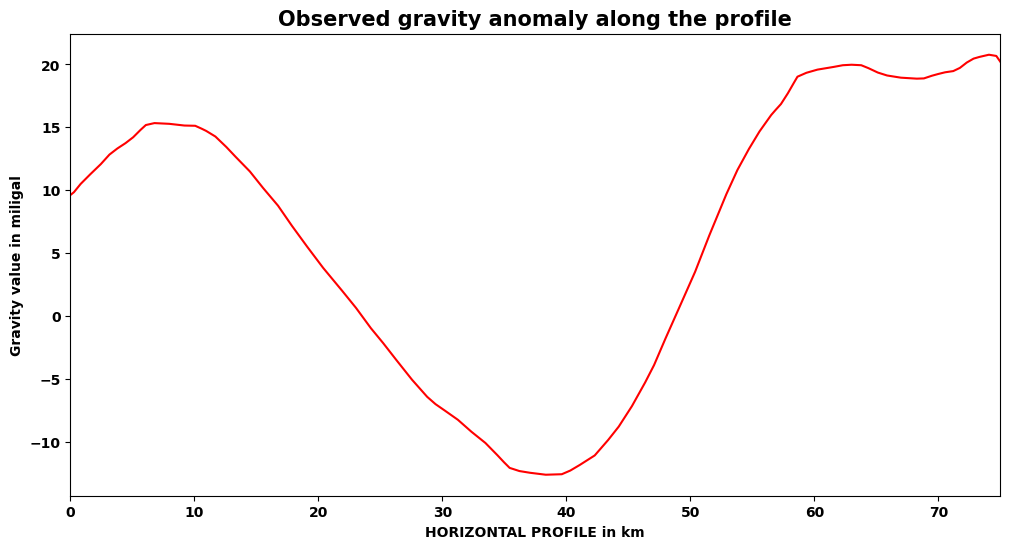

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data["depth_profile"],data["Gravity_value"],'r')
plt.xlim(0,75)
plt.xlabel("HORIZONTAL PROFILE in km",weight="bold")
plt.ylabel("Gravity value in miligal",weight="bold")
plt.title("Observed gravity anomaly along the profile",weight="bold",fontsize=15)
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')

In [ ]:
#Interpolating gravity anomaly data into 50 observed station points
NUM_INIT_POINTS=50
y_f=interp1d(data["depth_profile"],data["Gravity_value"],'linear')
X =np.linspace(1,75,NUM_INIT_POINTS) # Observation station co-ordinates
y= y_f(X) #Observed anomaly at stations in miligal
X_test = np.linspace(1,75, 200) #points taken for testing at finer intervals
ground_truth=y_f(X_test) #gravity anomaly at finer intervals for testing

In [ ]:
#FOR second layer
z9_f=interp1d(DATA9['X'],DATA9['Z'],'linear')
x9_new=np.arange(0,74+1,2) #Horizontal Profile
z9=z9_f(x9_new)   #Depth

#FOR bottom most LAYER
z10_f=interp1d(DATA10['X'],DATA10['Z'],'linear')
x10_new=np.arange(0,74+1,2) #Horizontal Profile
z10=z10_f(x10_new)   #Depth

#Fault1
z11_f=interp1d(DATA11['X'],DATA11['Z'],'linear')
x11=np.arange(min(DATA11['X']),max(DATA11['X']),2)
z11=z11_f(x11)

#Fault2
z12_f=interp1d(DATA12['X'],DATA12['Z'],'linear')
x12=np.arange(min(DATA12['X']),56+1,2)
z12=z12_f(x12)

#topmost layer
x13=np.arange(0,74+1,2) #Horizontal Profile
z13=np.zeros(len(x13))
for i in range(len(x13)):
  z13[i]=0.3738
#smoothing of depth profile of the top depth of basement
from scipy.signal import savgol_filter
z10hat = savgol_filter(z10, 5, 3) # window size 5, polynomial order 3

(array([ 0.,  2.,  4.,  6.,  8., 10.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10')])

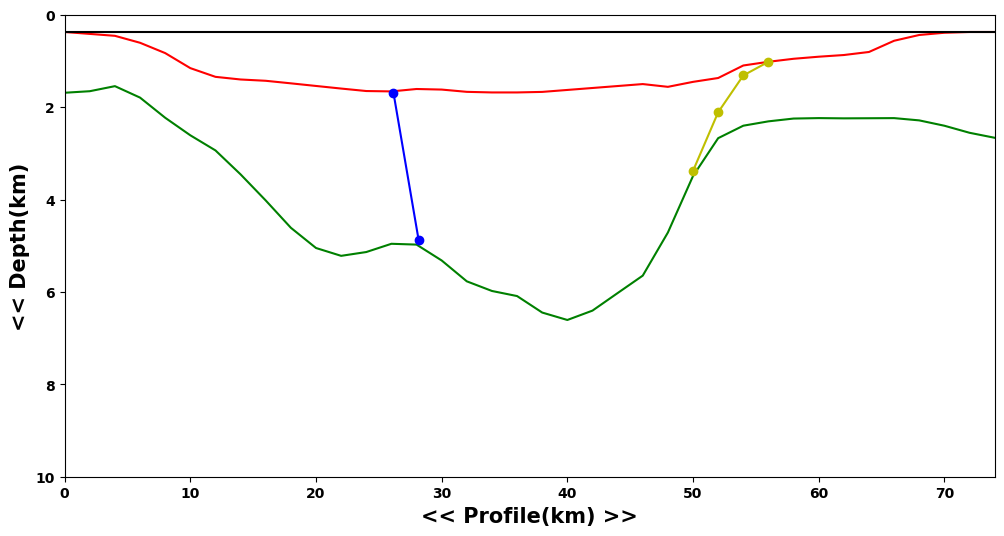

In [ ]:
#Plotting depth profile by the prior author
plt.figure(figsize=(12,6))
plt.plot(x9_new,z9,'r')
plt.plot(x10_new,z10hat,'g' )
plt.plot(x11,z11,'o-b' )
plt.plot(x12,z12,'o-y' )
plt.plot(x13,z13,'k')
plt.xlim(0,74)
plt.ylim(10,0)
plt.xlabel("<< Profile(km) >>",weight="bold",fontsize=15)
plt.ylabel("<< Depth(km)",weight="bold",fontsize=15)
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')

In [ ]:
#prior information of densities by the previous author
#sediment layer in the Miocene era
rho1=2020 #density of topmost surface layer
#sediment layer in the Paleocene era
rho2=2150 #density of 2nd layer (next to topmost layer)
#Fault system made in cretaceous jurrasic era
#western subbasin
rho3=2500 #density of 3rd layer (the leftside layer of the fault colored by blue)
#central subbasin
rho4=2450 #density of 4th layer (the rightside layer of the fault colored by blue and leftside layer of the fault colored by yellow)
#eastern subbasin
rho5=2550 #density of 5th layer (the rightside layer of the fault colored by yellow)
#basement
rho6=2650 #density of the basement layer

In [ ]:
n=37 #We are considering 37 prisms

wid=np.zeros(n)
td=np.zeros(n)
bd6=np.zeros(n)

#surface value in meter
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)

# Defining centre value of horizontal co-ordinate of each prism
co=np.arange(1000,73000+1,2000) #considering profile in meter

# Defining width of each prism
for j in range(n):
    wid[j]= 2000 # in meter

#Defining bottommost depth as we are considering thickness of 10km
for j in range(n):
    bd6[j]= 10000 # in meter

In [ ]:
bottom_depth_1st = z13 *1000 #bottom depth of layer 1 in meter (sediment layer in the Miocene era)
bottom_depth_2nd = z9 *1000 #bottom depth of layer 2 in meter (sediment layer in the Paleocene era)
top_depth_6th = z10hat *1000 #top depth of layer 6 (basement)
fault1_depth = z11*1000 #depth profile between 3rd and 4th layers in meter(western and central sub-basin)
fault2_depth = z12*1000 #depth profile between 4th and 5th layers in meter(central and eastern sub-basin)

In [ ]:
#Creating x co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
xss1=np.zeros(n+1)
xss1[0]=co[0]-(wid[0]*0.5)
for i in range(1,n):
    xss1[i]=co[i-1]+(0.5*wid[i-1])
xss1[n]=xss1[n-1]+wid[n-1]

#Creating z1 (bottom depth) co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
zss1=np.zeros(n+1)
for i in range(n+1):
    zss1[i]=bottom_depth_1st[i]

#Creating surface points
zss0=np.zeros(n+1)
R00=np.zeros(((n+1),2))
for i in range(n+1):
    R00[i]=[xss1[i],zss0[i]]

#Creating points for 1st layer(sediment layer in the Miocene era) bottom
R11=np.zeros(((n+1),2))
for i in range(n+1):
    R11[i]=[xss1[i],zss1[i]]


#Creating bottom depth co-ordinate values for 6th layer(basement) for each prism
zss6=np.zeros(n+1)
for i in range(n+1):
    zss6[i]=10000

#Creating points for 6th layer(basement) bottom
R66=np.zeros(((n+1),2))
for i in range(n+1):
    R66[i]=[xss1[i],zss6[i]]

#Creating top depth co-ordinate values for 6th layer(basement) top for each prism
zss6_top=np.zeros(n+1)
for i in range(n+1):
    zss6_top[i]=top_depth_6th[i]

#creating points for 6th layer(basement) top
R66_top=np.zeros(((n+1),2))
for i in range(n+1):
    R66_top[i]=[xss1[i],zss6_top[i]]

#Creating bottom depth co-ordinate values for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
zss2=np.zeros(n+1)
for i in range(n+1):
    zss2[i]=bottom_depth_2nd[i]

#Creating points for 2nd layer(sediment layer in the Paleocene era) bottom
R22=np.zeros(((n+1),2))
for i in range(n+1):
    R22[i]=[xss1[i],zss2[i]]

#Creating points for 2nd layer(sediment layer in the Paleocene era) TOP
R22_top=np.zeros(((n+1),2))
for i in range(n+1):
    R22_top[i]=[xss1[i],zss1[i]]

###Fault system made in cretaceous jurrasic era ###

#for 3rd layer(western subbasin)
#x coordinates of 3rd layer
xss3=np.arange(0,29000,2000)
#top depth coordinates of 3rd layer
zss3_top=np.zeros(len(xss3))
for i in range(len(xss3)-1):
    zss3_top[i]=zss2[i]
zss3_top[len(xss3)-1]=fault1_depth[1]
#bottom depth coordinates of 3rd layer
zss3=np.zeros(len(xss3))
for i in range(len(xss3)):
    zss3[i]=top_depth_6th[i]
#Creating points for 3rd layer TOP
R33_top=np.zeros(((len(xss3)),2))
for i in range(len(xss3)):
    R33_top[i]=[xss3[i],zss3_top[i]]
#Creating points for 3rd layer bottom
R33=np.zeros(((len(xss3)),2))
for i in range(len(xss3)):
    R33[i]=[xss3[i],zss3[i]]

#for 4th layer(central subbasin)
#x coordinates of 4th layer
xss4=np.arange(26000,57000,2000)
#top depth coordinates of 4th layer
zss4_top=np.zeros(len(xss4))
for i in range(len(xss4)):
    zss4_top[i]=zss2[i+13]
#bottom depth coordinates of 4th layer
zss4=np.zeros(len(xss4))
zss4[0]=fault1_depth[0]
zss4[1]=fault1_depth[1]
for i in range(len(xss4)-6):
    zss4[i+2]=top_depth_6th[i+15]
zss4[len(xss4)-1]=fault2_depth[3]
zss4[len(xss4)-2]=fault2_depth[2]
zss4[len(xss4)-3]=fault2_depth[1]
zss4[len(xss4)-4]=fault2_depth[0]
#Creating points for 4th layer TOP
R44_top=np.zeros(((len(xss4)),2))
for i in range(len(xss4)):
    R44_top[i]=[xss4[i],zss4_top[i]]
#Creating points for 4th layer bottom
R44=np.zeros(((len(xss4)),2))
for i in range(len(xss4)):
    R44[i]=[xss4[i],zss4[i]]

#for 5th layer (Eastern subbasin)
#x coordinates of 5th layer
xss5=np.arange(50000,75000,2000)
#top depth coordinates of 5th layer
zss5_top=np.zeros(len(xss5))
for i in range(len(xss5)-3):
    zss5_top[i+3]=zss2[i+28]
zss5_top[0]=fault2_depth[0]
zss5_top[1]=fault2_depth[1]
zss5_top[2]=fault2_depth[2]
#bottom depth coordinates of 5th layer
zss5=np.zeros(len(xss5))
for i in range(len(xss5)):
    zss5[i]=top_depth_6th[i+25]
#Creating points for 5th layer TOP
R55_top=np.zeros(((len(xss5)),2))
for i in range(len(xss5)):
    R55_top[i]=[xss5[i],zss5_top[i]]
#Creating points for 5th layer bottom
R55=np.zeros(((len(xss5)),2))
for i in range(len(xss5)):
    R55[i]=[xss5[i],zss5[i]]

Text(0, 0.5, '<< -- DEPTH (m)')

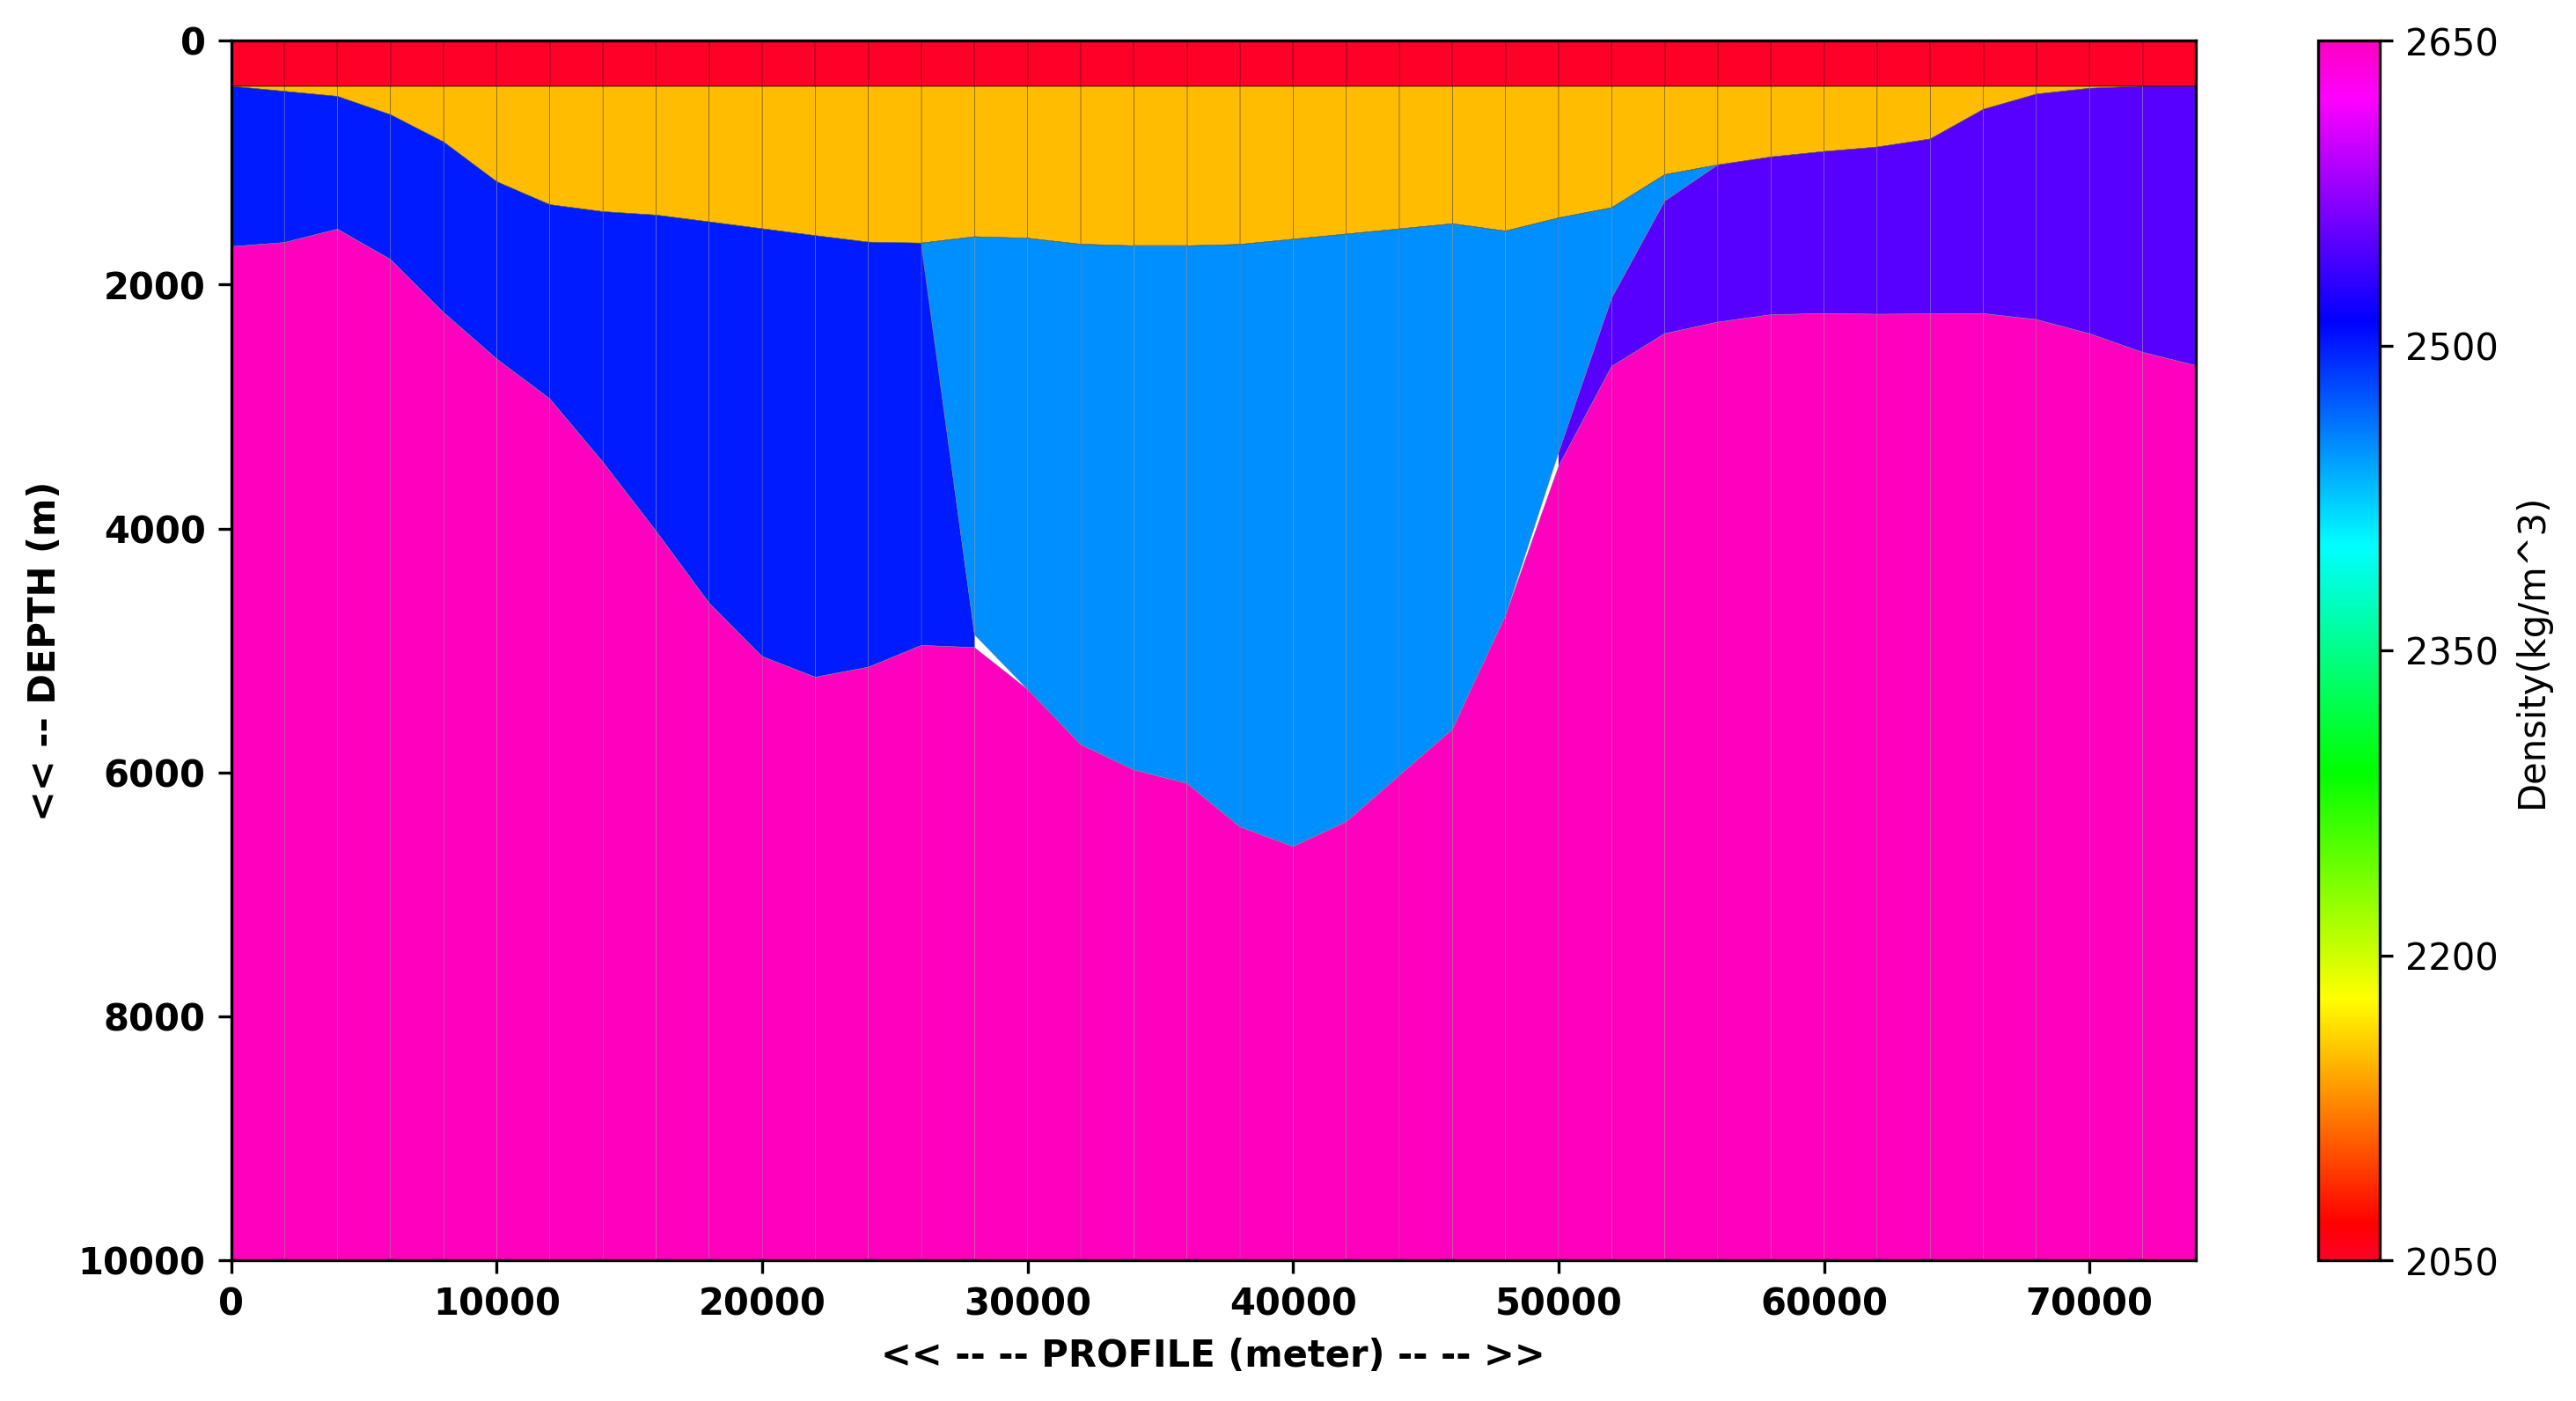

In [ ]:
#Visualization of prior model
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axs = plt.subplots(1)
fig.dpi=300
fig.set_size_inches(12, 6)
cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=2650 #maximum density value in color scale in kg/m^3
minimum_V=2050 #minimum density value in color scale in kg/m^3
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100) #creating colorscale dividng the min to max range in 100 equal values
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting color scale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=[axs],label='Density(kg/m^3)')

for i in range(n):
    #choosing the color depending upon the density value of 1st layer
    index_value_V1 = (rho1-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the density value of 6th layer
    index_value_V6 = (rho6-minimum_V)/diff_V
    color_V6 = cmap_V(index_value_V6)
    #choosing the color depending upon the density value of 2nd layer
    index_value_V2 = (rho2-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)

    #creating a prism using 4 corner co-ordinates
    coord1 = [R00[i], R00[i+1], R11[i+1], R11[i]]
    coord2 = [R22_top[i], R22_top[i+1], R22[i+1], R22[i]]
    coord6 = [R66_top[i], R66_top[i+1], R66[i+1], R66[i]]
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    xs6, ys6 = zip(*coord6) #create lists of x and y values

    axs.plot(xs1,ys1,'k',linewidth=0.1) #plotting each prism of layer 1
    axs.fill(xs1, ys1, facecolor=color_V1) #color filling the prism acc to its density value
    axs.plot(xs2,ys2,'k',linewidth=0.1) #plotting each prism of layer 2
    axs.fill(xs2, ys2, facecolor=color_V2) #color filling the prism acc to its density value
    axs.plot(xs6,ys6,'grey',linewidth=0.1)#plotting each prism of layer 6
    axs.fill(xs6, ys6, facecolor=color_V6) #color filling the prism acc to its density value

for i in range(len(xss3)-1):
    #choosing the color depending upon the density value of 3rd layer
    index_value_V3 = (rho3-minimum_V)/diff_V
    color_V3 = cmap_V(index_value_V3)
    #creating a prism using 4 corner co-ordinates
    coord3 = [R33_top[i], R33_top[i+1], R33[i+1], R33[i]]
    xs3, ys3 = zip(*coord3) #create lists of x and y values
    axs.plot(xs3,ys3,'grey',linewidth=0.1)#plotting each prism of layer 3
    axs.fill(xs3, ys3, facecolor=color_V3)#color filling the prism acc to its density value

for i in range(len(xss4)-1):
    #choosing the color depending upon the density value of 4th layer
    index_value_V4 = (rho4-minimum_V)/diff_V
    color_V4 = cmap_V(index_value_V4)
    #creating a prism using 4 corner co-ordinates
    coord4 = [R44_top[i], R44_top[i+1], R44[i+1], R44[i]]
    xs4, ys4 = zip(*coord4) #create lists of x and y values
    axs.plot(xs4,ys4,'grey',linewidth=0.1)#plotting each prism of layer 4
    axs.fill(xs4, ys4, facecolor=color_V4)#color filling the prism acc to its density value

for i in range(len(xss5)-1):
    #choosing the color depending upon the density value of 4th layer
    index_value_V5 = (rho5-minimum_V)/diff_V
    color_V5 = cmap_V(index_value_V5)
    #creating a prism using 4 corner co-ordinates
    coord5 = [R55_top[i], R55_top[i+1], R55[i+1], R55[i]]
    xs5, ys5 = zip(*coord5) #create lists of x and y values
    axs.plot(xs5,ys5,'grey',linewidth=0.1)#plotting each prism of layer 5
    axs.fill(xs5, ys5, facecolor=color_V5)#color filling the prism acc to its density value

axs.set_xlim(0,74000) #showing 74 km horizontal profile
axs.set_ylim(10000,0) #10 km depth
plt.setp(axs.get_xticklabels(), visible= True,weight='bold')
plt.setp(axs.get_yticklabels(), visible= True,weight='bold')
#axs.set_title("FAULT Representation by Prisms",weight='bold')
axs.set_xlabel("<< -- -- PROFILE (meter) -- -- >>",weight='bold')
axs.set_ylabel("<< -- DEPTH (m)",weight='bold')


In [ ]:
from typing import Dict
import jax.numpy as jnp

In [ ]:
#DO NOT RUN
for i in range(n+1):
    print(f"\"Bottom_depth2_{i+1}\" : numpyro.sample""("f"\"Bottom_depth2_{i+1}\""", numpyro.distributions.Uniform"f"({-100+bottom_depth_2nd[i]}, {150+bottom_depth_2nd[i]})),")

In [ ]:
#Prior range of inverting model parameters
def Bayes_Inf_prior():
    return{
        "density1" : numpyro.sample("density1", numpyro.distributions.Uniform(1900, 2100)),
        "density2" : numpyro.sample("density2", numpyro.distributions.Uniform(2100, 2300)),
        "density3" : numpyro.sample("density3", numpyro.distributions.Uniform(2450, 2650)),
        "density4" : numpyro.sample("density4", numpyro.distributions.Uniform(2300, 2450)),
        "density5" : numpyro.sample("density5", numpyro.distributions.Uniform(2450, 2650)),
        "density6" : numpyro.sample("density6", numpyro.distributions.Uniform(2650, 2800)),
        "fault1_depth_1": numpyro.sample("fault1_depth_1", numpyro.distributions.Uniform(1588,1838)),
        "fault1_depth_2": numpyro.sample("fault1_depth_2", numpyro.distributions.Uniform(3871,5021)),
        "fault2_depth_1": numpyro.sample("fault2_depth_1", numpyro.distributions.Uniform(3278,3528)),
        "fault2_depth_2": numpyro.sample("fault2_depth_2", numpyro.distributions.Uniform(2010,2260)),
        "fault2_depth_3": numpyro.sample("fault2_depth_3", numpyro.distributions.Uniform(1214,1464)),
        "fault2_depth_4": numpyro.sample("fault2_depth_4", numpyro.distributions.Uniform(900,1168)),
        "Bottom_depth1_1" : numpyro.sample("Bottom_depth1_1", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_2" : numpyro.sample("Bottom_depth1_2", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_3" : numpyro.sample("Bottom_depth1_3", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_4" : numpyro.sample("Bottom_depth1_4", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_5" : numpyro.sample("Bottom_depth1_5", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_6" : numpyro.sample("Bottom_depth1_6", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_7" : numpyro.sample("Bottom_depth1_7", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_8" : numpyro.sample("Bottom_depth1_8", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_9" : numpyro.sample("Bottom_depth1_9", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_10" : numpyro.sample("Bottom_depth1_10", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_11" : numpyro.sample("Bottom_depth1_11", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_12" : numpyro.sample("Bottom_depth1_12", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_13" : numpyro.sample("Bottom_depth1_13", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_14" : numpyro.sample("Bottom_depth1_14", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_15" : numpyro.sample("Bottom_depth1_15", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_16" : numpyro.sample("Bottom_depth1_16", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_17" : numpyro.sample("Bottom_depth1_17", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_18" : numpyro.sample("Bottom_depth1_18", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_19" : numpyro.sample("Bottom_depth1_19", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_20" : numpyro.sample("Bottom_depth1_20", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_21" : numpyro.sample("Bottom_depth1_21", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_22" : numpyro.sample("Bottom_depth1_22", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_23" : numpyro.sample("Bottom_depth1_23", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_24" : numpyro.sample("Bottom_depth1_24", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_25" : numpyro.sample("Bottom_depth1_25", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_26" : numpyro.sample("Bottom_depth1_26", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_27" : numpyro.sample("Bottom_depth1_27", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_28" : numpyro.sample("Bottom_depth1_28", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_29" : numpyro.sample("Bottom_depth1_29", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_30" : numpyro.sample("Bottom_depth1_30", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_31" : numpyro.sample("Bottom_depth1_31", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_32" : numpyro.sample("Bottom_depth1_32", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_33" : numpyro.sample("Bottom_depth1_33", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_34" : numpyro.sample("Bottom_depth1_34", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_35" : numpyro.sample("Bottom_depth1_35", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_36" : numpyro.sample("Bottom_depth1_36", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_37" : numpyro.sample("Bottom_depth1_37", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth1_38" : numpyro.sample("Bottom_depth1_38", numpyro.distributions.Uniform(273.8, 473.8)),
        "Bottom_depth2_1" : numpyro.sample("Bottom_depth2_1", numpyro.distributions.Uniform(273.8316, 523.8316)),
        "Bottom_depth2_2" : numpyro.sample("Bottom_depth2_2", numpyro.distributions.Uniform(315.23632500666764, 565.2363250066676)),
        "Bottom_depth2_3" : numpyro.sample("Bottom_depth2_3", numpyro.distributions.Uniform(356.6410500133352, 606.6410500133352)),
        "Bottom_depth2_4" : numpyro.sample("Bottom_depth2_4", numpyro.distributions.Uniform(507.2831371989288, 757.2831371989288)),
        "Bottom_depth2_5" : numpyro.sample("Bottom_depth2_5", numpyro.distributions.Uniform(730.662860904072, 980.662860904072)),
        "Bottom_depth2_6" : numpyro.sample("Bottom_depth2_6", numpyro.distributions.Uniform(1055.9850923314698, 1305.9850923314698)),
        "Bottom_depth2_7" : numpyro.sample("Bottom_depth2_7", numpyro.distributions.Uniform(1244.6562823737806, 1494.6562823737806)),
        "Bottom_depth2_8" : numpyro.sample("Bottom_depth2_8", numpyro.distributions.Uniform(1301.8690000000001, 1551.8690000000001)),
        "Bottom_depth2_9" : numpyro.sample("Bottom_depth2_9", numpyro.distributions.Uniform(1330.0385916025011, 1580.0385916025011)),
        "Bottom_depth2_10" : numpyro.sample("Bottom_depth2_10", numpyro.distributions.Uniform(1385.2449405275609, 1635.2449405275609)),
        "Bottom_depth2_11" : numpyro.sample("Bottom_depth2_11", numpyro.distributions.Uniform(1441.8612946472626, 1691.8612946472626)),
        "Bottom_depth2_12" : numpyro.sample("Bottom_depth2_12", numpyro.distributions.Uniform(1498.2040206486124, 1748.2040206486124)),
        "Bottom_depth2_13" : numpyro.sample("Bottom_depth2_13", numpyro.distributions.Uniform(1551.7866394648502, 1801.7866394648502)),
        "Bottom_depth2_14" : numpyro.sample("Bottom_depth2_14", numpyro.distributions.Uniform(1559.7774974756123, 1809.7774974756123)),
        "Bottom_depth2_15" : numpyro.sample("Bottom_depth2_15", numpyro.distributions.Uniform(1507.7258234154, 1757.7258234154)),
        "Bottom_depth2_16" : numpyro.sample("Bottom_depth2_16", numpyro.distributions.Uniform(1520.1060607902173, 1770.1060607902173)),
        "Bottom_depth2_17" : numpyro.sample("Bottom_depth2_17", numpyro.distributions.Uniform(1569.344108612101, 1819.344108612101)),
        "Bottom_depth2_18" : numpyro.sample("Bottom_depth2_18", numpyro.distributions.Uniform(1582.243, 1832.243)),
        "Bottom_depth2_19" : numpyro.sample("Bottom_depth2_19", numpyro.distributions.Uniform(1582.243, 1832.243)),
        "Bottom_depth2_20" : numpyro.sample("Bottom_depth2_20", numpyro.distributions.Uniform(1570.5643644879092, 1820.5643644879092)),
        "Bottom_depth2_21" : numpyro.sample("Bottom_depth2_21", numpyro.distributions.Uniform(1528.1967406457507, 1778.1967406457507)),
        "Bottom_depth2_22" : numpyro.sample("Bottom_depth2_22", numpyro.distributions.Uniform(1485.8291168035923, 1735.8291168035923)),
        "Bottom_depth2_23" : numpyro.sample("Bottom_depth2_23", numpyro.distributions.Uniform(1443.4614929614338, 1693.4614929614338)),
        "Bottom_depth2_24" : numpyro.sample("Bottom_depth2_24", numpyro.distributions.Uniform(1401.0938691192755, 1651.0938691192755)),
        "Bottom_depth2_25" : numpyro.sample("Bottom_depth2_25", numpyro.distributions.Uniform(1460.9033645984778, 1710.9033645984778)),
        "Bottom_depth2_26" : numpyro.sample("Bottom_depth2_26", numpyro.distributions.Uniform(1353.1795686880444, 1603.1795686880444)),
        "Bottom_depth2_27" : numpyro.sample("Bottom_depth2_27", numpyro.distributions.Uniform(1269.860269788862, 1519.860269788862)),
        "Bottom_depth2_28" : numpyro.sample("Bottom_depth2_28", numpyro.distributions.Uniform(998.8951390489945, 1248.8951390489945)),
        "Bottom_depth2_29" : numpyro.sample("Bottom_depth2_29", numpyro.distributions.Uniform(918.6468885298858, 1168.646888529886)),
        "Bottom_depth2_30" : numpyro.sample("Bottom_depth2_30", numpyro.distributions.Uniform(853.5823689198927, 1103.5823689198928)),
        "Bottom_depth2_31" : numpyro.sample("Bottom_depth2_31", numpyro.distributions.Uniform(808.7848730532012, 1058.7848730532012)),
        "Bottom_depth2_32" : numpyro.sample("Bottom_depth2_32", numpyro.distributions.Uniform(772.3487215042612, 1022.3487215042612)),
        "Bottom_depth2_33" : numpyro.sample("Bottom_depth2_33", numpyro.distributions.Uniform(706.3965060289538, 956.3965060289538)),
        "Bottom_depth2_34" : numpyro.sample("Bottom_depth2_34", numpyro.distributions.Uniform(463.489339640608, 713.489339640608)),
        "Bottom_depth2_35" : numpyro.sample("Bottom_depth2_35", numpyro.distributions.Uniform(338.3340546625081, 588.3340546625082)),
        "Bottom_depth2_36" : numpyro.sample("Bottom_depth2_36", numpyro.distributions.Uniform(290.3916319434898, 540.3916319434898)),
        "Bottom_depth2_37" : numpyro.sample("Bottom_depth2_37", numpyro.distributions.Uniform(273.8316, 523.8316)),
        "Bottom_depth2_38" : numpyro.sample("Bottom_depth2_38", numpyro.distributions.Uniform(273.8316, 523.8316)),
        "top_depth6_1" : numpyro.sample("top_depth6_1", numpyro.distributions.Uniform(1582.243, 1832.243)),
        "top_depth6_2" : numpyro.sample("top_depth6_2", numpyro.distributions.Uniform(1582.243, 1832.243)),
        "top_depth6_3" : numpyro.sample("top_depth6_3", numpyro.distributions.Uniform(1405.8496627744973, 1655.8496627744973)),
        "top_depth6_4" : numpyro.sample("top_depth6_4", numpyro.distributions.Uniform(1606.2120455501877, 1856.2120455501877)),
        "top_depth6_5" : numpyro.sample("top_depth6_5", numpyro.distributions.Uniform(2268.700587328989, 2518.700587328989)),
        "top_depth6_6" : numpyro.sample("top_depth6_6", numpyro.distributions.Uniform(2450.7781426246156, 2700.7781426246156)),
        "top_depth6_7" : numpyro.sample("top_depth6_7", numpyro.distributions.Uniform(2824.110494712424, 3074.110494712424)),
        "top_depth6_8" : numpyro.sample("top_depth6_8", numpyro.distributions.Uniform(3370.6531835625424, 3620.6531835625424)),
        "top_depth6_9" : numpyro.sample("top_depth6_9", numpyro.distributions.Uniform(3920.01291602501, 4170.01291602501)),
        "top_depth6_10" : numpyro.sample("top_depth6_10", numpyro.distributions.Uniform(4472.076405275609, 4722.076405275609)),
        "top_depth6_11" : numpyro.sample("top_depth6_11", numpyro.distributions.Uniform(5019.6248876846375, 5269.6248876846375)),
        "top_depth6_12" : numpyro.sample("top_depth6_12", numpyro.distributions.Uniform(5092.45178694336, 5342.45178694336)),
        "top_depth6_13" : numpyro.sample("top_depth6_13", numpyro.distributions.Uniform(5040.400669835727, 5290.400669835727)),
        "top_depth6_14" : numpyro.sample("top_depth6_14", numpyro.distributions.Uniform(4904.11205544401, 5154.11205544401)),
        "top_depth6_15" : numpyro.sample("top_depth6_15", numpyro.distributions.Uniform(4767.4762207867525, 5017.4762207867525)),
        "top_depth6_16" : numpyro.sample("top_depth6_16", numpyro.distributions.Uniform(5251.1358750965965, 5501.1358750965965)),
        "top_depth6_17" : numpyro.sample("top_depth6_17", numpyro.distributions.Uniform(5712.945492113342, 5962.945492113342)),
        "top_depth6_18" : numpyro.sample("top_depth6_18", numpyro.distributions.Uniform(5881.308, 6131.308)),
        "top_depth6_19" : numpyro.sample("top_depth6_19", numpyro.distributions.Uniform(5974.7660000000005, 6224.7660000000005)),
        "top_depth6_20" : numpyro.sample("top_depth6_20", numpyro.distributions.Uniform(6233.291555419823, 6483.291555419823)),
        "top_depth6_21" : numpyro.sample("top_depth6_21", numpyro.distributions.Uniform(6722.429999999999, 6972.429999999999)),
        "top_depth6_22" : numpyro.sample("top_depth6_22", numpyro.distributions.Uniform(6184.2748055496695, 6434.2748055496695)),
        "top_depth6_23" : numpyro.sample("top_depth6_23", numpyro.distributions.Uniform(5870.905867724958, 6120.905867724958)),
        "top_depth6_24" : numpyro.sample("top_depth6_24", numpyro.distributions.Uniform(5633.278631287662, 5883.278631287662)),
        "top_depth6_25" : numpyro.sample("top_depth6_25", numpyro.distributions.Uniform(4693.402737744958, 4943.402737744958)),
        "top_depth6_26" : numpyro.sample("top_depth6_26", numpyro.distributions.Uniform(3278.8600574753154, 3528.8600574753154)),
        "top_depth6_27" : numpyro.sample("top_depth6_27", numpyro.distributions.Uniform(2543.9037417137215, 2793.9037417137215)),
        "top_depth6_28" : numpyro.sample("top_depth6_28", numpyro.distributions.Uniform(2343.3906180354916, 2593.3906180354916)),
        "top_depth6_29" : numpyro.sample("top_depth6_29", numpyro.distributions.Uniform(2205.9415123638173, 2455.9415123638173)),
        "top_depth6_30" : numpyro.sample("top_depth6_30", numpyro.distributions.Uniform(2142.99, 2392.99)),
        "top_depth6_31" : numpyro.sample("top_depth6_31", numpyro.distributions.Uniform(2142.99, 2392.99)),
        "top_depth6_32" : numpyro.sample("top_depth6_32", numpyro.distributions.Uniform(2142.99, 2392.99)),
        "top_depth6_33" : numpyro.sample("top_depth6_33", numpyro.distributions.Uniform(2142.99, 2392.99)),
        "top_depth6_34" : numpyro.sample("top_depth6_34", numpyro.distributions.Uniform(2142.99, 2392.99)),
        "top_depth6_35" : numpyro.sample("top_depth6_35", numpyro.distributions.Uniform(2170.116706692958, 2420.116706692958)),
        "top_depth6_36" : numpyro.sample("top_depth6_36", numpyro.distributions.Uniform(2310.2557090846385, 2560.2557090846385)),
        "top_depth6_37" : numpyro.sample("top_depth6_37", numpyro.distributions.Uniform(2450.3947114763196, 2700.3947114763196)),
        "top_depth6_38" : numpyro.sample("top_depth6_38", numpyro.distributions.Uniform(2564.734721780914, 2814.734721780914)),
    }

In [ ]:
#DO NOT RUN THIS CELL
for i in range(n+1):
    print(f"\"Bottom_depth2_{i+1}\" :"f"{bottom_depth_2nd[i]},")

In [ ]:
#Defining model
from os import name
#First defining the function g_ano() replacing jnp in place of np to calculate gravity anomaly due to one single prism.
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    d=10**-5
    r1=((((x*1000)-A)+(0.5*m))**2)+((d)**2)
    r2=((((x*1000)-A)+(0.5*m))**2)+((D)**2)
    r3=((((x*1000)-A)-(0.5*m))**2)+((d)**2)
    r4=((((x*1000)-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan(((x*1000)-A+(0.5*m))/(D))-jnp.arctan(((x*1000)-A-(0.5*m))/(D))
    f2=jnp.arctan(((x*1000)-A+(0.5*m))/d)-jnp.arctan(((x*1000)-A-(0.5*m))/d)
    f3=0.5*((x*1000)-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    return 2*G*rho*f

#defining the function Bayes_1st() to calculate gravity anomaly due to prisms of 1st layer due to contrast in density of 1st and 2nd layer.
def Bayes_1st(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density2-density1
    for i in range(n):
        B_D1 = 0.5*(params[f"Bottom_depth1_{i+1+1}"]+params[f"Bottom_depth1_{i+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D1),td[i],rho)
        u=u+v
    return u

#defining the function Bayes_2nd_A() to calculate gravity anomaly due to prisms of 2nd layer above the western sub-basin side due to contrast in density of 2nd and 3rd layer.
def Bayes_2nd_A(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density3-density2
    for i in range(14):
        B_D2 = 0.5*(params[f"Bottom_depth2_{i+1+1}"]+params[f"Bottom_depth2_{i+1}"])
        B_D2_top=0.5*(params[f"Bottom_depth1_{i+1+1}"]+params[f"Bottom_depth1_{i+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D2),abs(B_D2_top),rho)
        u=u+v
    return u

#defining the function Bayes_2nd_B() to calculate gravity anomaly due to prisms of 2nd layer above the central sub-basin side due to contrast in density of 2nd and 4th layer.
def Bayes_2nd_B(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density4-density2
    for i in range(14,29):
        B_D2 = 0.5*(params[f"Bottom_depth2_{i+1+1}"]+params[f"Bottom_depth2_{i+1}"])
        B_D2_top=0.5*(params[f"Bottom_depth1_{i+1+1}"]+params[f"Bottom_depth1_{i+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D2),abs(B_D2_top),rho)
        u=u+v
    return u

#defining the function Bayes_2nd_C() to calculate gravity anomaly due to prisms of 2nd layer above the eastern sub-basin side due to contrast in density of 2nd and 5th layer.
def Bayes_2nd_C(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density5-density2
    for i in range(29,n):
        B_D2 = 0.5*(params[f"Bottom_depth2_{i+1+1}"]+params[f"Bottom_depth2_{i+1}"])
        B_D2_top=0.5*(params[f"Bottom_depth1_{i+1+1}"]+params[f"Bottom_depth1_{i+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D2),abs(B_D2_top),rho)
        u=u+v
    return u

#defining the function Bayes_3rd() to calculate gravity anomaly due to prisms of 3rd layer due to contrast in density of 3rd and basement layer.
def Bayes_3rd(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density3
    for i in range(len(xss3)-1):
        B_D3 = 0.5*(params[f"top_depth6_{i+1+1}"]+params[f"top_depth6_{i+1}"])
        B_D3_top=0.5*(params[f"Bottom_depth2_{i+1+1}"]+params[f"Bottom_depth2_{i+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D3),abs(B_D3_top),rho)
        u=u+v
    return u

#defining the function Bayes_4th_A(),Bayes_4th_B(),Bayes_4th_C() to calculate gravity anomaly due to prisms of 4th layer due to contrast in density of 4th and basement layer.
def Bayes_4th_A(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density4
    for i in range(0,2):
        bottom=params[f"fault1_depth_{i+1}"]
        #B_D4 = 0.5*(params[f"top_depth6_{i+13+1+1}"]+params[f"top_depth6_{i+13+1}"])
        B_D4_top=0.5*(params[f"Bottom_depth2_{i+13+1+1}"]+params[f"Bottom_depth2_{i+13+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(bottom),abs(B_D4_top),rho)
        u=u+v
    return u

def Bayes_4th_B(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density4
    for i in range(2,len(xss4)-5):
        B_D4 = 0.5*(params[f"top_depth6_{i+13+1+1}"]+params[f"top_depth6_{i+13+1}"])
        B_D4_top=0.5*(params[f"Bottom_depth2_{i+13+1+1}"]+params[f"Bottom_depth2_{i+13+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D4),abs(B_D4_top),rho)
        u=u+v
    return u
def Bayes_4th_C(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density4
    for i in range(0,4):
        bottom=params[f"fault2_depth_{i+1}"]
        #B_D4 = 0.5*(params[f"top_depth6_{i+13+1+1}"]+params[f"top_depth6_{i+13+1}"])
        B_D4_top=0.5*(params[f"Bottom_depth2_{i+13+1+1+20}"]+params[f"Bottom_depth2_{i+13+1+20}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(bottom),abs(B_D4_top),rho)
        u=u+v
    return u

#defining the function Bayes_5th_A() and Bayes_5th_B() to calculate gravity anomaly due to prisms of 5th layer due to contrast in density of 5th and basement layer.
def Bayes_5th_A(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density5
    for i in range(3):
        top=params[f"fault2_depth_{i+1}"]
        B_D5 = 0.5*(params[f"top_depth6_{i+25+1+1}"]+params[f"top_depth6_{i+25+1}"])
        #B_D5_top=0.5*(0.5*(params[f"top_depth6_{i+25+1+1}"]+params[f"top_depth6_{i+25+1}"]))
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D5),abs(top),rho)
        u=u+v
    return u

def Bayes_5th_B(x,params):
    u=0
    density1 = params["density1"]
    density2 = params["density2"]
    density3 = params["density3"]
    density4 = params["density4"]
    density5 = params["density5"]
    density6 = params["density6"]
    rho=density6-density5
    for i in range(3,len(xss5)-1):
        B_D5 = 0.5*(params[f"top_depth6_{i+25+1+1}"]+params[f"top_depth6_{i+25+1}"])
        B_D5_top = 0.5*(params[f"Bottom_depth2_{i+25+1+1}"]+params[f"Bottom_depth2_{i+25+1}"])
        #B_D5_top = 0.5*(params[f"top_depth6_{i+25+1+1}"]+params[f"top_depth6_{i+25+1}"])
        G=6.67*(10**-6)
        v=g_ano(x,co[i],wid[i],abs(B_D5),abs(B_D5_top),rho)
        u=u+v
    return u

#defining Bayes_Inf() based on the prior knowledge of gravity anomaly generation for layers to use in the inversion.
def Bayes_Inf(x,params):
    return Bayes_1st(x,params)+Bayes_2nd_A(x,params)+Bayes_2nd_B(x,params)+Bayes_2nd_C(x,params)+Bayes_3rd(x,params)+Bayes_4th_A(x,params)+Bayes_4th_B(x,params)+Bayes_4th_C(x,params)+Bayes_5th_A(x,params)+Bayes_5th_B(x,params)

# **STRUCTURAL GP**

In [ ]:
## checking with structural gaussian  ###
rng_key, rng_key_predict = gpax.utils.get_keys(1)
mean_fn = [Bayes_Inf]
mean_fn_priors = [Bayes_Inf_prior]
for m, mp in zip(mean_fn, mean_fn_priors):
    # Initialize model
    gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=m, mean_fn_prior=mp)
    # Run MCMC to obtain posterior samples
    gp_model.fit(rng_key, X, y, num_warmup=200, num_samples=75, num_chains=1)
    # Get GP prediction
    y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, n=200)

sample: 100%|██████████| 275/275 [04:08<00:00,  1.11it/s, 15 steps of size 3.73e-01. acc. prob=0.86]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    376.70     48.63    376.79    308.41    451.87     77.57      0.99
  Bottom_depth1_10    377.75     54.24    382.20    287.68    448.24    137.14      0.99
  Bottom_depth1_11    357.11     54.47    352.02    283.51    441.32    113.62      0.99
  Bottom_depth1_12    363.91     54.57    359.84    289.70    450.15    121.83      0.99
  Bottom_depth1_13    391.06     62.22    402.74    282.73    473.57    498.96      0.99
  Bottom_depth1_14    364.57     63.97    357.31    274.30    454.99    100.11      1.01
  Bottom_depth1_15    366.00     54.86    366.42    288.98    453.88    136.99      0.99
  Bottom_depth1_16    388.12     55.43    388.21    305.21    471.87    213.33      0.99
  Bottom_depth1_17    365.60     53.09    353.08    289.05    449.90    204.38      0.99
  Bottom_depth1_18    368.02     55.30    369.78    294.26    461.46    135.22      1.00
  Bottom_depth1_19  

In [ ]:
#Getting inverted parameters
params1 = gp_model.get_samples()
#Defining arrays with inverted results

#bottom depth of layer 1 in meter (sediment layer in the Miocene era)
Bottom_Depth_1st_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_1st_Layer[i]=params1[f'Bottom_depth1_{i+1}'].mean()
#bottom depth of layer 2 in meter (sediment layer in the Paleocene era)
Bottom_Depth_2nd_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_2nd_Layer[i]=params1[f'Bottom_depth2_{i+1}'].mean()
#top depth of layer 6 (basement)
Top_Depth_6th_Layer=np.zeros(n+1)
for i in range(n+1):
    Top_Depth_6th_Layer[i]=params1[f'top_depth6_{i+1}'].mean()
#depth profile between 3rd and 4th layers in meter(western and central sub-basin)
fault1_depth_I=np.zeros(2)
fault1_depth_I[0]=params1[f'fault1_depth_1'].mean()
fault1_depth_I[1]=params1[f'fault1_depth_2'].mean()
#depth profile between 4th and 5th layers in meter(central and eastern sub-basin)
fault2_depth_I=np.zeros(4)
for i in range(4):
    fault2_depth_I[i]=params1[f'fault2_depth_{i+1}'].mean()

In [ ]:
##CREATING POINTS WITH INVERTED RESULTS##

#Creating x co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
xs1=np.zeros(n+1)
xs1[0]=co[0]-(wid[0]*0.5)
for i in range(1,n):
    xs1[i]=co[i-1]+(0.5*wid[i-1])
xs1[n]=xs1[n-1]+wid[n-1]

#Creating z1 (bottom depth) co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
zs1=np.zeros(n+1)
for i in range(n+1):
    zs1[i]=Bottom_Depth_1st_Layer[i]

#Creating surface points
zs0=np.zeros(n+1)
R00_I=np.zeros(((n+1),2))
for i in range(n+1):
    R00_I[i]=[xs1[i],zs0[i]]

#Creating points for 1st layer(sediment layer in the Miocene era) bottom
R11_I=np.zeros(((n+1),2))
for i in range(n+1):
    R11_I[i]=[xs1[i],zs1[i]]

#Creating bottom depth co-ordinate values for 6th layer(basement) for each prism
zs6=np.zeros(n+1)
for i in range(n+1):
    zs6[i]=10000
#Creating bottom CO-ordinates for 6th layer(basement) for each prism
R66_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_I[i]=[xs1[i],zs6[i]]
#Creating top depth co-ordinate values for 6th layer(basement) top for each prism
zs6_top=np.zeros(n+1)
for i in range(n+1):
    zs6_top[i]=Top_Depth_6th_Layer[i]
#Creating top points for 6th layer(basement) top for each prism
R66_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_top_I[i]=[xs1[i],zs6_top[i]]

#Creating bottom depth co-ordinate values for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
zs2=np.zeros(n+1)
for i in range(n+1):
    zs2[i]=Bottom_Depth_2nd_Layer[i]

#Creating bottom points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_I[i]=[xs1[i],zs2[i]]

#Creating top points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_top_I[i]=[xs1[i],zs1[i]]



In [ ]:
#for 3rd layer(western subbasin)
#x coordinates of 3rd layer
xs3=np.arange(0,29000,2000)
#top depth coordinates of 3rd layer
zs3_top=np.zeros(len(xs3))
for i in range(len(xs3)-1):
    zs3_top[i]=zs2[i]
zs3_top[len(xs3)-1]=fault1_depth_I[1]
#bottom depth coordinates of 3rd layer
zs3=np.zeros(len(xs3))
for i in range(len(xs3)):
    zs3[i]=Top_Depth_6th_Layer[i]
#Creating points for 3rd layer TOP
R33_top_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_top_I[i]=[xs3[i],zs3_top[i]]
#Creating points for 3rd layer bottom
R33_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_I[i]=[xs3[i],zs3[i]]

#for 4th layer
#x coordinates of 4th layer
xs4=np.arange(26000,57000,2000)
#top depth coordinates of 4th layer
zs4_top=np.zeros(len(xs4))
for i in range(len(xs4)):
    zs4_top[i]=zs2[i+13]
#bottom depth coordinates of 4th layer
zs4=np.zeros(len(xs4))
zs4[0]=fault1_depth_I[0]
#zs4[1]=fault1_depth_I[1]
for i in range(len(xs4)-5):
    zs4[i+2-1]=Top_Depth_6th_Layer[i+15-1]
zs4[len(xs4)-1]=fault2_depth_I[3]
zs4[len(xs4)-2]=fault2_depth_I[2]
zs4[len(xs4)-3]=fault2_depth_I[1]
zs4[len(xs4)-4]=fault2_depth_I[0]
#Creating points for 4th layer TOP depth
R44_top_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_top_I[i]=[xs4[i],zs4_top[i]]
#Creating points for 4th layer bottom depth
R44_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_I[i]=[xs4[i],zs4[i]]

#for 5th layer
#x coordinates of 4th layer
xs5=np.arange(50000,75000,2000)
#top depth coordinates of 5th layer
zs5_top=np.zeros(len(xs5))
for i in range(len(xs5)-3):
    zs5_top[i+3]=zs2[i+28]
zs5_top[0]=fault2_depth_I[0]
zs5_top[1]=fault2_depth_I[1]
zs5_top[2]=fault2_depth_I[2]
#bottom depth coordinates of 5th layer
zs5=np.zeros(len(xs5))
for i in range(len(xs5)):
    zs5[i]=Top_Depth_6th_Layer[i+25]
#Creating points for 5th layer TOP
R55_top_I=np.zeros(((len(xs5)),2))
for i in range(len(xss5)):
    R55_top_I[i]=[xs5[i],zs5_top[i]]
#Creating points for 5th layer bottom
R55_I=np.zeros(((len(xs5)),2))
for i in range(len(xs5)):
    R55_I[i]=[xs5[i],zs5[i]]

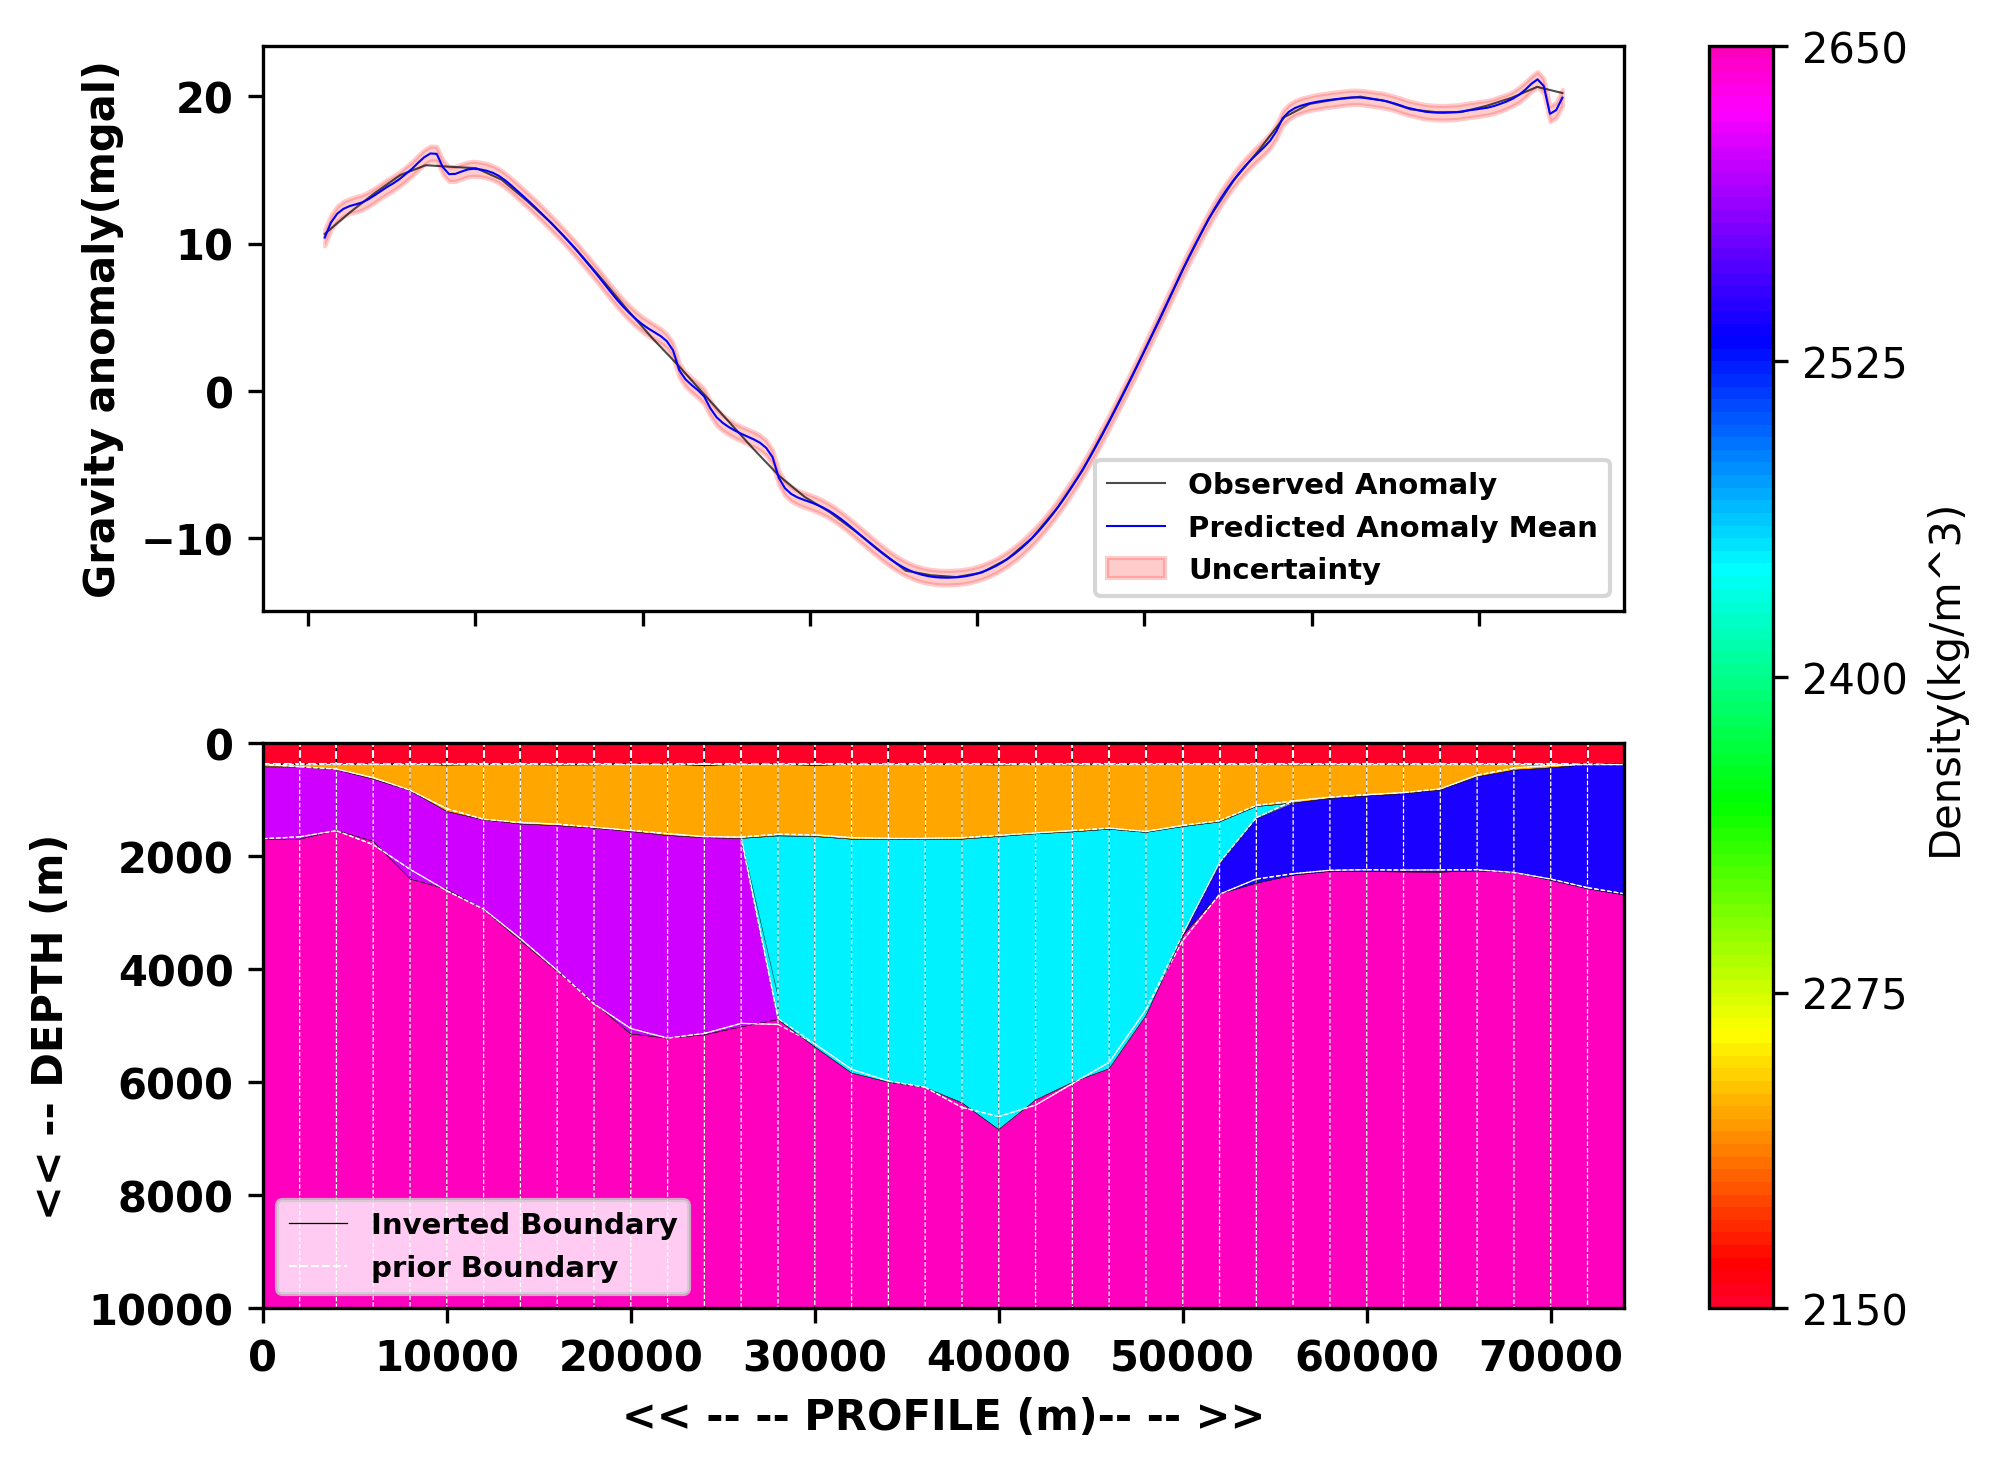

In [ ]:
### TESTING PLOT ###
#PLOT THE INVERTED RESULTS
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.08)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=2650#maximum density in kg per m^3 in colorscale
minimum_V=2150#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(kg/m^3)')
for i in range(n):
    #choosing the color depending upon the inverted density value of 1st layer
    index_value_V1 = (params1[f'density1'].mean()-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the inverted density value of 6th layer
    index_value_V6 = (params1[f'density6'].mean()-minimum_V)/diff_V
    color_V6 = cmap_V(index_value_V6)
    #choosing the color depending upon the inverted density value of 2nd layer
    index_value_V2 = (params1[f'density2'].mean()-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord1_I = [R00_I[i], R00_I[i+1], R11_I[i+1], R11_I[i]]
    coord2_I = [R22_top_I[i], R22_top_I[i+1], R22_I[i+1], R22_I[i]]
    coord6_I = [R66_top_I[i], R66_top_I[i+1], R66_I[i+1], R66_I[i]]
    xs1_I, ys1_I = zip(*coord1_I) #create lists of x and y values
    xs2_I, ys2_I = zip(*coord2_I) #create lists of x and y values
    xs6_I, ys6_I = zip(*coord6_I) #create lists of x and y values
    #creating a prism using 4 corner co-ordinates using previous results
    coord1_R = [R00[i], R00[i+1], R11[i+1], R11[i]]
    coord2_R = [R22_top[i], R22_top[i+1], R22[i+1], R22[i]]
    coord6_R = [R66_top[i], R66_top[i+1], R66[i+1], R66[i]]
    xs1_R, ys1_R = zip(*coord1_R) #create lists of x and y values
    xs2_R, ys2_R = zip(*coord2_R) #create lists of x and y values
    xs6_R, ys6_R = zip(*coord6_R) #create lists of x and y values

    axs[1].plot(xs1_I,ys1_I,'k',linewidth=0.3)#plotting each prism of layer 1
    axs[1].plot(xs1_R,ys1_R,'white',linestyle='dashed',linewidth=0.5)
    axs[1].fill(xs1_I, ys1_I, facecolor=color_V1)#color filling the prism acc to its inverted density value
    axs[1].plot(xs2_I,ys2_I,'k',linewidth=0.1)#plotting each prism of layer 2
    axs[1].fill(xs2_I, ys2_I, facecolor=color_V2)#color filling the prism acc to its inverted density value
    axs[1].plot(xs6_I,ys6_I,'k',linewidth=0.1)#plotting each prism of layer 6
    axs[1].fill(xs6_I, ys6_I, facecolor=color_V6)#color filling the prism acc to its inverted density value
    #axs[1].plot(xs1_R,ys1_R,'white',linestyle='dashed',linewidth=0.3)
    axs[1].plot(xs2_R,ys2_R,'white',linestyle='dashed',linewidth=0.3)
    axs[1].plot(xs6_R,ys6_R,'white',linestyle='dashed',linewidth=0.3)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['Inverted Boundary','prior Boundary'],prop=legend_properties)

for i in range(len(xss3)-1):
    #choosing the color depending upon the inverted density value of 3rd layer
    index_value_V3 = (params1[f'density3'].mean()-minimum_V)/diff_V
    color_V3 = cmap_V(index_value_V3)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord3_I = [R33_top_I[i], R33_top_I[i+1], R33_I[i+1], R33_I[i]]
    xs3_I, ys3_I = zip(*coord3_I) #create lists of x and y values
    axs[1].plot(xs3_I,ys3_I,'k',linewidth=0.1)#plotting each prism of layer 3 using inverted result
    axs[1].fill(xs3_I, ys3_I, facecolor=color_V3)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord3_R = [R33_top[i], R33_top[i+1], R33[i+1], R33[i]]
    xs3_R, ys3_R = zip(*coord3_R) #create lists of x and y values
    axs[1].plot(xs3_R,ys3_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss4)-1):
    #choosing the color depending upon the inverted density value of 4th layer
    index_value_V4 = (params1[f'density4'].mean()-minimum_V)/diff_V
    color_V4 = cmap_V(index_value_V4)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord4_I = [R44_top_I[i], R44_top_I[i+1], R44_I[i+1], R44_I[i]]
    xs4_I, ys4_I = zip(*coord4_I) #create lists of x and y values
    axs[1].plot(xs4_I,ys4_I,'k',linewidth=0.1)#plotting each prism of layer 4 using inverted result
    axs[1].fill(xs4_I, ys4_I, facecolor=color_V4)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord4_R = [R44_top[i], R44_top[i+1], R44[i+1], R44[i]]
    xs4_R, ys4_R = zip(*coord4_R) #create lists of x and y values
    axs[1].plot(xs4_R,ys4_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss5)-1):
    #choosing the color depending upon the inverted density value of 5th layer
    index_value_V5 = (params1[f'density5'].mean()-minimum_V)/diff_V
    color_V5 = cmap_V(index_value_V5)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord5_I = [R55_top_I[i], R55_top_I[i+1], R55_I[i+1], R55_I[i]]
    xs5_I, ys5_I = zip(*coord5_I) #create lists of x and y values
    axs[1].plot(xs5_I,ys5_I,'k',linewidth=0.1)#plotting each prism of layer 5 using inverted result
    axs[1].fill(xs5_I, ys5_I, facecolor=color_V5)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord5_R = [R55_top[i], R55_top[i+1], R55[i+1], R55[i]]
    xs5_R, ys5_R = zip(*coord5_R) #create lists of x and y values
    axs[1].plot(xs5_R,ys5_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 5 using previous knowledge

    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['Inverted Boundary','prior Boundary'],prop=legend_properties)
axs[1].set_xlim(0,74000)
axs[1].set_ylim(10000,0)
axs[1].set_xlabel("<< -- -- PROFILE (m)-- -- >>",weight='bold')
axs[1].set_ylabel("<< -- DEPTH (m)",weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')



axs[0].set_ylabel("Gravity anomaly(mgal)",fontsize=10,weight='bold')
axs[0].plot(X, y, c='k',lw=0.5, zorder=1, label="Observed Anomaly", alpha=0.7)
#for y1 in y_sampled:
    #axs[0].plot(X_test, y1.mean(0), lw=.1, zorder=0, c='r', alpha=.1)
#l, = axs[0].plot(X_test, y_sampled[0].mean(0), lw=1, c='r', alpha=1, label="Sampled predictions")#sampled predictions
axs[0].plot(X_test, y_pred, lw=0.5,zorder=1, c='b', label='Predicted Anomaly Mean') #mean of the sampled predictions
axs[0].fill_between(X_test, y_pred - y_sampled.std((0,1)), y_pred + y_sampled.std((0,1)),color='r', alpha=0.2, label="Uncertainty", zorder=0)

#axs[0].plot(X_test, measure_func(X_test, noise=0), c='k', linestyle='--', label='True function', alpha=0.5)#true anomaly
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(prop=legend_properties)
#axs[0].legend(loc='upper left')
#l.set_alpha(0)
#plt.show()

# **ACTIVE LEARNING WITH STRUCTURAL GAUSSIAN**

In [ ]:
#Some initial guess of inverting model parameters
PARAMS={
    "top_depth6_1" :1682.243,
    "top_depth6_2" :1682.243,
    "top_depth6_3" :1505.8496627744973,
    "top_depth6_4" :1706.2120455501877,
    "top_depth6_5" :2368.700587328989,
    "top_depth6_6" :2550.7781426246156,
    "top_depth6_7" :2924.110494712424,
    "top_depth6_8" :3470.6531835625424,
    "top_depth6_9" :4020.01291602501,
    "top_depth6_10" :4572.076405275609,
    "top_depth6_11" :5119.6248876846375,
    "top_depth6_12" :5192.45178694336,
    "top_depth6_13" :5140.400669835727,
    "top_depth6_14" :5004.11205544401,
    "top_depth6_15" :4867.4762207867525,
    "top_depth6_16" :5351.1358750965965,
    "top_depth6_17" :5812.945492113342,
    "top_depth6_18" :5981.308,
    "top_depth6_19" :6074.7660000000005,
    "top_depth6_20" :6333.291555419823,
    "top_depth6_21" :6822.429999999999,
    "top_depth6_22" :6284.2748055496695,
    "top_depth6_23" :5970.905867724958,
    "top_depth6_24" :5733.278631287662,
    "top_depth6_25" :4793.402737744958,
    "top_depth6_26" :3378.8600574753154,
    "top_depth6_27" :2643.9037417137215,
    "top_depth6_28" :2443.3906180354916,
    "top_depth6_29" :2305.9415123638173,
    "top_depth6_30" :2242.99,
    "top_depth6_31" :2242.99,
    "top_depth6_32" :2242.99,
    "top_depth6_33" :2242.99,
    "top_depth6_34" :2242.99,
    "top_depth6_35" :2270.116706692958,
    "top_depth6_36" :2410.2557090846385,
    "top_depth6_37" :2550.3947114763196,
    "top_depth6_38" :2664.734721780914,
    "Bottom_depth1_1" :373.8,
    "Bottom_depth1_2" :373.8,
    "Bottom_depth1_3" :373.8,
    "Bottom_depth1_4" :373.8,
    "Bottom_depth1_5" :373.8,
    "Bottom_depth1_6" :373.8,
    "Bottom_depth1_7" :373.8,
    "Bottom_depth1_8" :373.8,
    "Bottom_depth1_9" :373.8,
    "Bottom_depth1_10" :373.8,
    "Bottom_depth1_11" :373.8,
    "Bottom_depth1_12" :373.8,
    "Bottom_depth1_13" :373.8,
    "Bottom_depth1_14" :373.8,
    "Bottom_depth1_15" :373.8,
    "Bottom_depth1_16" :373.8,
    "Bottom_depth1_17" :373.8,
    "Bottom_depth1_18" :373.8,
    "Bottom_depth1_19" :373.8,
    "Bottom_depth1_20" :373.8,
    "Bottom_depth1_21" :373.8,
    "Bottom_depth1_22" :373.8,
    "Bottom_depth1_23" :373.8,
    "Bottom_depth1_24" :373.8,
    "Bottom_depth1_25" :373.8,
    "Bottom_depth1_26" :373.8,
    "Bottom_depth1_27" :373.8,
    "Bottom_depth1_28" :373.8,
    "Bottom_depth1_29" :373.8,
    "Bottom_depth1_30" :373.8,
    "Bottom_depth1_31" :373.8,
    "Bottom_depth1_32" :373.8,
    "Bottom_depth1_33" :373.8,
    "Bottom_depth1_34" :373.8,
    "Bottom_depth1_35" :373.8,
    "Bottom_depth1_36" :373.8,
    "Bottom_depth1_37" :373.8,
    "Bottom_depth1_38" :373.8,
    "Bottom_depth2_1" :373.8316,
    "Bottom_depth2_2" :415.23632500666764,
    "Bottom_depth2_3" :456.6410500133352,
    "Bottom_depth2_4" :607.2831371989288,
    "Bottom_depth2_5" :830.662860904072,
    "Bottom_depth2_6" :1155.9850923314698,
    "Bottom_depth2_7" :1344.6562823737806,
    "Bottom_depth2_8" :1401.8690000000001,
    "Bottom_depth2_9" :1430.0385916025011,
    "Bottom_depth2_10" :1485.2449405275609,
    "Bottom_depth2_11" :1541.8612946472626,
    "Bottom_depth2_12" :1598.2040206486124,
    "Bottom_depth2_13" :1651.7866394648502,
    "Bottom_depth2_14" :1659.7774974756123,
    "Bottom_depth2_15" :1607.7258234154,
    "Bottom_depth2_16" :1620.1060607902173,
    "Bottom_depth2_17" :1669.344108612101,
    "Bottom_depth2_18" :1682.243,
    "Bottom_depth2_19" :1682.243,
    "Bottom_depth2_20" :1670.5643644879092,
    "Bottom_depth2_21" :1628.1967406457507,
    "Bottom_depth2_22" :1585.8291168035923,
    "Bottom_depth2_23" :1543.4614929614338,
    "Bottom_depth2_24" :1501.0938691192755,
    "Bottom_depth2_25" :1560.9033645984778,
    "Bottom_depth2_26" :1453.1795686880444,
    "Bottom_depth2_27" :1369.860269788862,
    "Bottom_depth2_28" :1098.8951390489945,
    "Bottom_depth2_29" :1018.6468885298858,
    "Bottom_depth2_30" :953.5823689198927,
    "Bottom_depth2_31" :908.7848730532012,
    "Bottom_depth2_32" :872.3487215042612,
    "Bottom_depth2_33" :806.3965060289538,
    "Bottom_depth2_34" :563.489339640608,
    "Bottom_depth2_35" :438.3340546625081,
    "Bottom_depth2_36" :390.3916319434898,
    "Bottom_depth2_37" :373.8316,
    "Bottom_depth2_38" :373.8316,
    "density1":2061,
    "density2":2228,
    "density3":2608,
    "density4":2444,
    "density5":2547,
    "density6":2653,
    "fault1_depth_1":1688.5,
    "fault1_depth_2":4871.5,
    "fault2_depth_1":3378.86006,
    "fault2_depth_2":2110.902,
    "fault2_depth_3":1314.368,
    "fault2_depth_4":1018.646
}

In [ ]:

# Copy the initial observations so that we can re-use them later
Xo, yo = X.copy(), y.copy()
rng_key, rng_key_predict = gpax.utils.get_keys(1)

for i in range(2):
    print("\nExploration step {}".format(i+1))

    # Obtain/update GP posterior
    gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_Inf, mean_fn_prior=Bayes_Inf_prior)
    gp_model.fit(rng_key, Xo, yo, num_warmup = 200, num_samples = 75, num_chains = 1, print_summary=1)

    # Compute acquisition function (here it is simply the uncertinty in prediciton)
    # and get the coordinate of the next point to measure
    obj = gpax.acquisition.UE(rng_key_predict, gp_model, X_test)
    next_point_idx = obj.argmax()

     # Append the 'suggested' point
    Xo = np.append(Xo, X_test[next_point_idx])
    measured = Bayes_Inf(X_test[next_point_idx],PARAMS)
    yo = np.append(yo, measured)


Exploration step 1


sample: 100%|██████████| 275/275 [04:11<00:00,  1.09it/s, 15 steps of size 3.73e-01. acc. prob=0.86]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    376.70     48.63    376.79    308.41    451.87     77.57      0.99
  Bottom_depth1_10    377.75     54.24    382.20    287.68    448.24    137.14      0.99
  Bottom_depth1_11    357.11     54.47    352.02    283.51    441.32    113.62      0.99
  Bottom_depth1_12    363.91     54.57    359.84    289.70    450.15    121.83      0.99
  Bottom_depth1_13    391.06     62.22    402.74    282.73    473.57    498.96      0.99
  Bottom_depth1_14    364.57     63.97    357.31    274.30    454.99    100.11      1.01
  Bottom_depth1_15    366.00     54.86    366.42    288.98    453.88    136.99      0.99
  Bottom_depth1_16    388.12     55.43    388.21    305.21    471.87    213.33      0.99
  Bottom_depth1_17    365.60     53.09    353.08    289.05    449.90    204.38      0.99
  Bottom_depth1_18    368.02     55.30    369.78    294.26    461.46    135.22      1.00
  Bottom_depth1_19  

sample: 100%|██████████| 275/275 [04:32<00:00,  1.01it/s, 15 steps of size 3.96e-01. acc. prob=0.85]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    373.42     48.01    365.94    290.91    446.67     66.76      1.03
  Bottom_depth1_10    372.60     59.50    376.41    282.85    458.37     79.68      0.99
  Bottom_depth1_11    378.83     46.68    380.06    293.11    440.64    168.62      0.99
  Bottom_depth1_12    366.50     54.38    358.20    289.09    451.44    162.74      0.99
  Bottom_depth1_13    367.08     49.45    359.74    274.31    425.90    132.14      0.99
  Bottom_depth1_14    373.38     60.98    378.02    277.46    455.34     64.09      1.02
  Bottom_depth1_15    373.72     49.73    371.14    299.71    462.19    107.02      1.00
  Bottom_depth1_16    380.02     59.31    375.39    292.52    468.74    129.91      0.99
  Bottom_depth1_17    377.92     57.21    384.26    293.10    462.22     85.37      1.03
  Bottom_depth1_18    364.22     55.23    359.29    274.32    449.18    171.60      0.99
  Bottom_depth1_19  

In [ ]:
#Make the prediction using all the newly discovered points
rng_key, rng_key_predict = gpax.utils.get_keys(1)
# Update GP posterior
gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_Inf, mean_fn_prior=Bayes_Inf_prior)
gp_model.fit(rng_key, Xo, yo, num_warmup = 200, num_samples = 75, num_chains = 1)
# Get GP prediction
y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, n=200)

sample: 100%|██████████| 275/275 [03:00<00:00,  1.52it/s, 15 steps of size 3.74e-01. acc. prob=0.86]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    372.63     50.74    377.33    294.85    443.32    121.31      1.00
  Bottom_depth1_10    370.45     51.26    371.01    289.06    450.67    147.61      0.99
  Bottom_depth1_11    369.60     48.99    371.97    292.07    441.34     96.89      1.01
  Bottom_depth1_12    369.60     58.95    358.32    283.13    447.00    238.12      0.99
  Bottom_depth1_13    378.65     56.77    383.54    299.40    473.21    496.55      0.99
  Bottom_depth1_14    371.58     59.59    369.74    280.91    452.13    143.93      0.99
  Bottom_depth1_15    371.08     65.55    377.09    276.42    463.33    134.72      0.99
  Bottom_depth1_16    372.88     62.82    368.97    287.05    472.84   -719.83      0.99
  Bottom_depth1_17    367.94     54.23    355.84    289.65    453.53    157.54      0.99
  Bottom_depth1_18    369.70     57.12    368.64    281.17    457.30    238.59      0.99
  Bottom_depth1_19  

In [ ]:
#Getting inverted parameters
params1 = gp_model.get_samples()
#Defining arrays with inverted results

#bottom depth of layer 1 in meter (sediment layer in the Miocene era)
Bottom_Depth_1st_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_1st_Layer[i]=params1[f'Bottom_depth1_{i+1}'].mean()
#bottom depth of layer 2 in meter (sediment layer in the Paleocene era)
Bottom_Depth_2nd_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_2nd_Layer[i]=params1[f'Bottom_depth2_{i+1}'].mean()
#top depth of layer 6 (basement)
Top_Depth_6th_Layer=np.zeros(n+1)
for i in range(n+1):
    Top_Depth_6th_Layer[i]=params1[f'top_depth6_{i+1}'].mean()
#depth profile between 3rd and 4th layers in meter(western and central sub-basin)
fault1_depth_I=np.zeros(2)
fault1_depth_I[0]=params1[f'fault1_depth_1'].mean()
fault1_depth_I[1]=params1[f'fault1_depth_2'].mean()
#depth profile between 4th and 5th layers in meter(central and eastern sub-basin)
fault2_depth_I=np.zeros(4)
for i in range(4):
    fault2_depth_I[i]=params1[f'fault2_depth_{i+1}'].mean()

In [ ]:
##CREATING POINTS WITH INVERTED RESULTS##

#Creating x co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
xs1=np.zeros(n+1)
xs1[0]=co[0]-(wid[0]*0.5)
for i in range(1,n):
    xs1[i]=co[i-1]+(0.5*wid[i-1])
xs1[n]=xs1[n-1]+wid[n-1]

#Creating z1 (bottom depth) co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
zs1=np.zeros(n+1)
for i in range(n+1):
    zs1[i]=Bottom_Depth_1st_Layer[i]

#Creating surface points
zs0=np.zeros(n+1)
R00_I=np.zeros(((n+1),2))
for i in range(n+1):
    R00_I[i]=[xs1[i],zs0[i]]

#Creating points for 1st layer(sediment layer in the Miocene era) bottom
R11_I=np.zeros(((n+1),2))
for i in range(n+1):
    R11_I[i]=[xs1[i],zs1[i]]

#Creating bottom depth co-ordinate values for 6th layer(basement) for each prism
zs6=np.zeros(n+1)
for i in range(n+1):
    zs6[i]=10000
#Creating bottom CO-ordinates for 6th layer(basement) for each prism
R66_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_I[i]=[xs1[i],zs6[i]]
#Creating top depth co-ordinate values for 6th layer(basement) top for each prism
zs6_top=np.zeros(n+1)
for i in range(n+1):
    zs6_top[i]=Top_Depth_6th_Layer[i]
#Creating top points for 6th layer(basement) top for each prism
R66_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_top_I[i]=[xs1[i],zs6_top[i]]

#Creating bottom depth co-ordinate values for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
zs2=np.zeros(n+1)
for i in range(n+1):
    zs2[i]=Bottom_Depth_2nd_Layer[i]

#Creating bottom points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_I[i]=[xs1[i],zs2[i]]

#Creating top points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_top_I[i]=[xs1[i],zs1[i]]



In [ ]:
#for 3rd layer(western subbasin)
#x coordinates of 3rd layer
xs3=np.arange(0,29000,2000)
#top depth coordinates of 3rd layer
zs3_top=np.zeros(len(xs3))
for i in range(len(xs3)-1):
    zs3_top[i]=zs2[i]
zs3_top[len(xs3)-1]=fault1_depth_I[1]
#bottom depth coordinates of 3rd layer
zs3=np.zeros(len(xs3))
for i in range(len(xs3)):
    zs3[i]=Top_Depth_6th_Layer[i]
#Creating points for 3rd layer TOP
R33_top_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_top_I[i]=[xs3[i],zs3_top[i]]
#Creating points for 3rd layer bottom
R33_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_I[i]=[xs3[i],zs3[i]]

#for 4th layer
#x coordinates of 4th layer
xs4=np.arange(26000,57000,2000)
#top depth coordinates of 4th layer
zs4_top=np.zeros(len(xs4))
for i in range(len(xs4)):
    zs4_top[i]=zs2[i+13]
#bottom depth coordinates of 4th layer
zs4=np.zeros(len(xs4))
zs4[0]=fault1_depth_I[0]
#zs4[1]=fault1_depth_I[1]
for i in range(len(xs4)-5):
    zs4[i+2-1]=Top_Depth_6th_Layer[i+15-1]
zs4[len(xs4)-1]=fault2_depth_I[3]
zs4[len(xs4)-2]=fault2_depth_I[2]
zs4[len(xs4)-3]=fault2_depth_I[1]
zs4[len(xs4)-4]=fault2_depth_I[0]
#Creating points for 4th layer TOP depth
R44_top_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_top_I[i]=[xs4[i],zs4_top[i]]
#Creating points for 4th layer bottom depth
R44_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_I[i]=[xs4[i],zs4[i]]

#for 5th layer
#x coordinates of 4th layer
xs5=np.arange(50000,75000,2000)
#top depth coordinates of 5th layer
zs5_top=np.zeros(len(xs5))
for i in range(len(xs5)-3):
    zs5_top[i+3]=zs2[i+28]
zs5_top[0]=fault2_depth_I[0]
zs5_top[1]=fault2_depth_I[1]
zs5_top[2]=fault2_depth_I[2]
#bottom depth coordinates of 5th layer
zs5=np.zeros(len(xs5))
for i in range(len(xs5)):
    zs5[i]=Top_Depth_6th_Layer[i+25]
#Creating points for 5th layer TOP
R55_top_I=np.zeros(((len(xs5)),2))
for i in range(len(xss5)):
    R55_top_I[i]=[xs5[i],zs5_top[i]]
#Creating points for 5th layer bottom
R55_I=np.zeros(((len(xs5)),2))
for i in range(len(xs5)):
    R55_I[i]=[xs5[i],zs5[i]]

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000')])

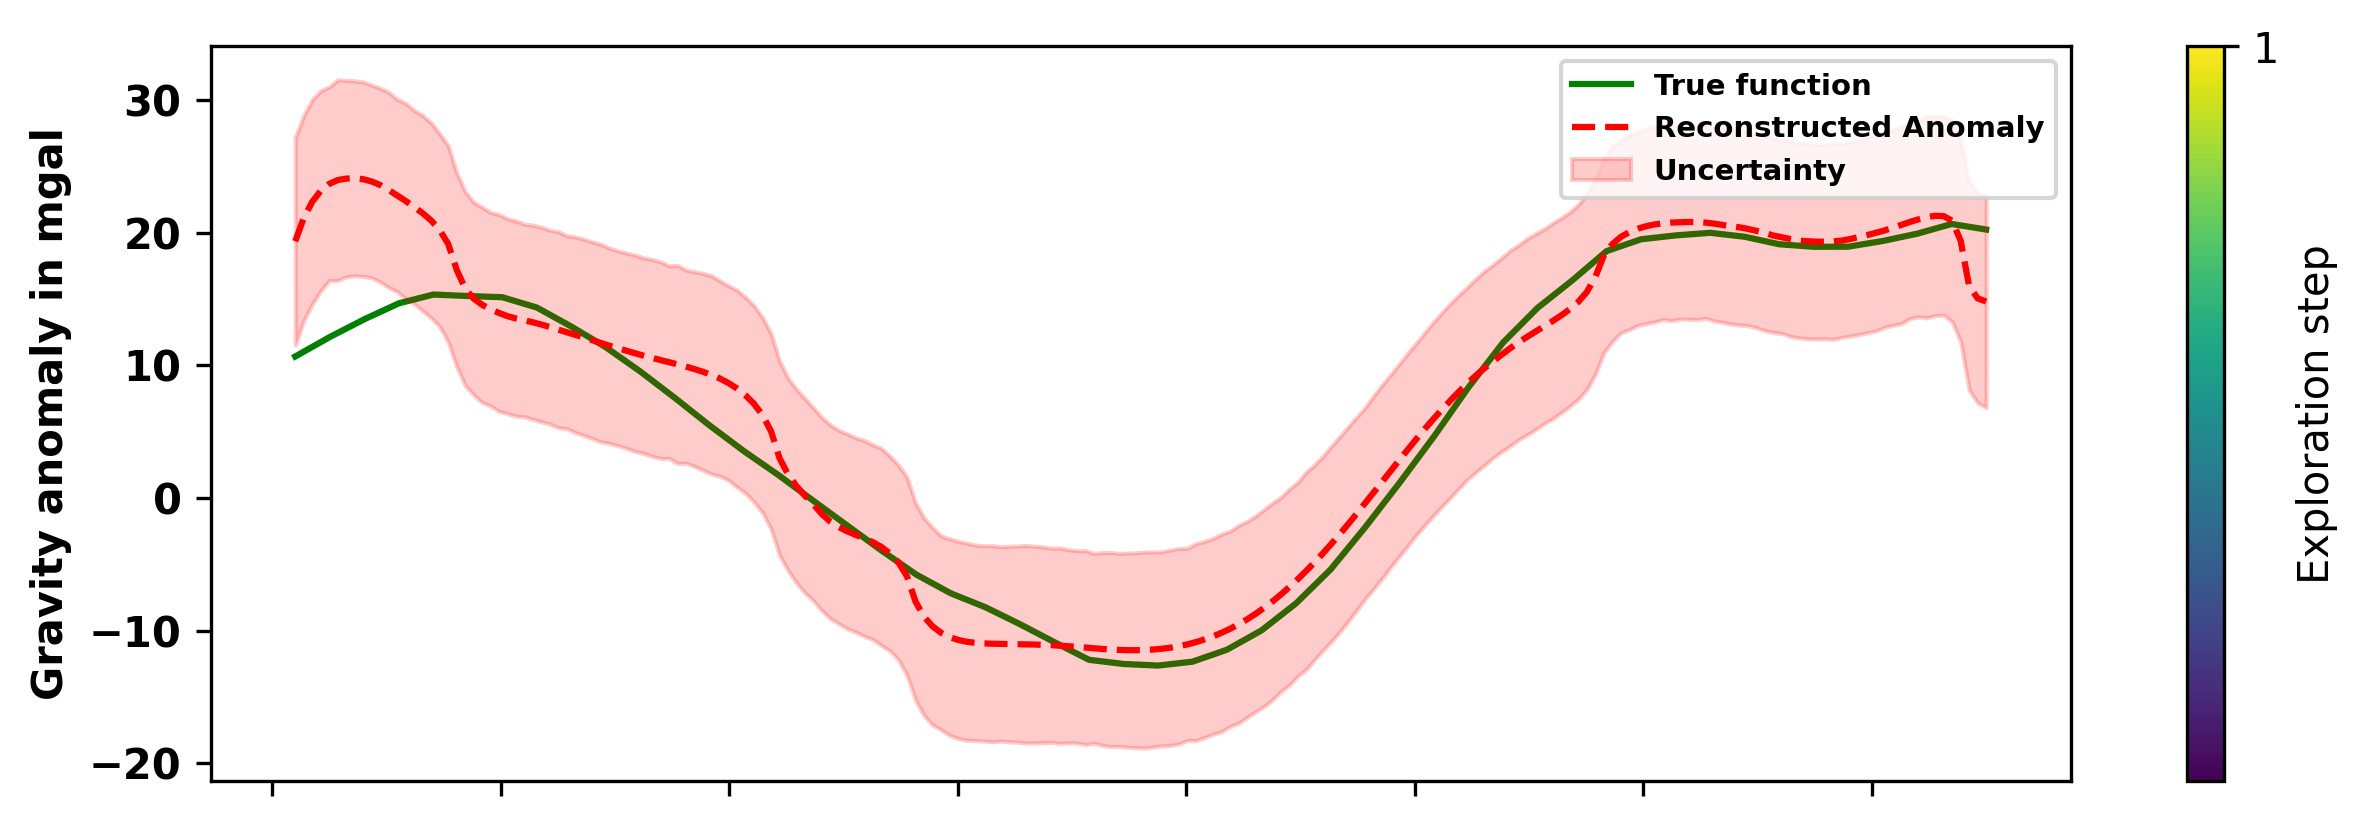

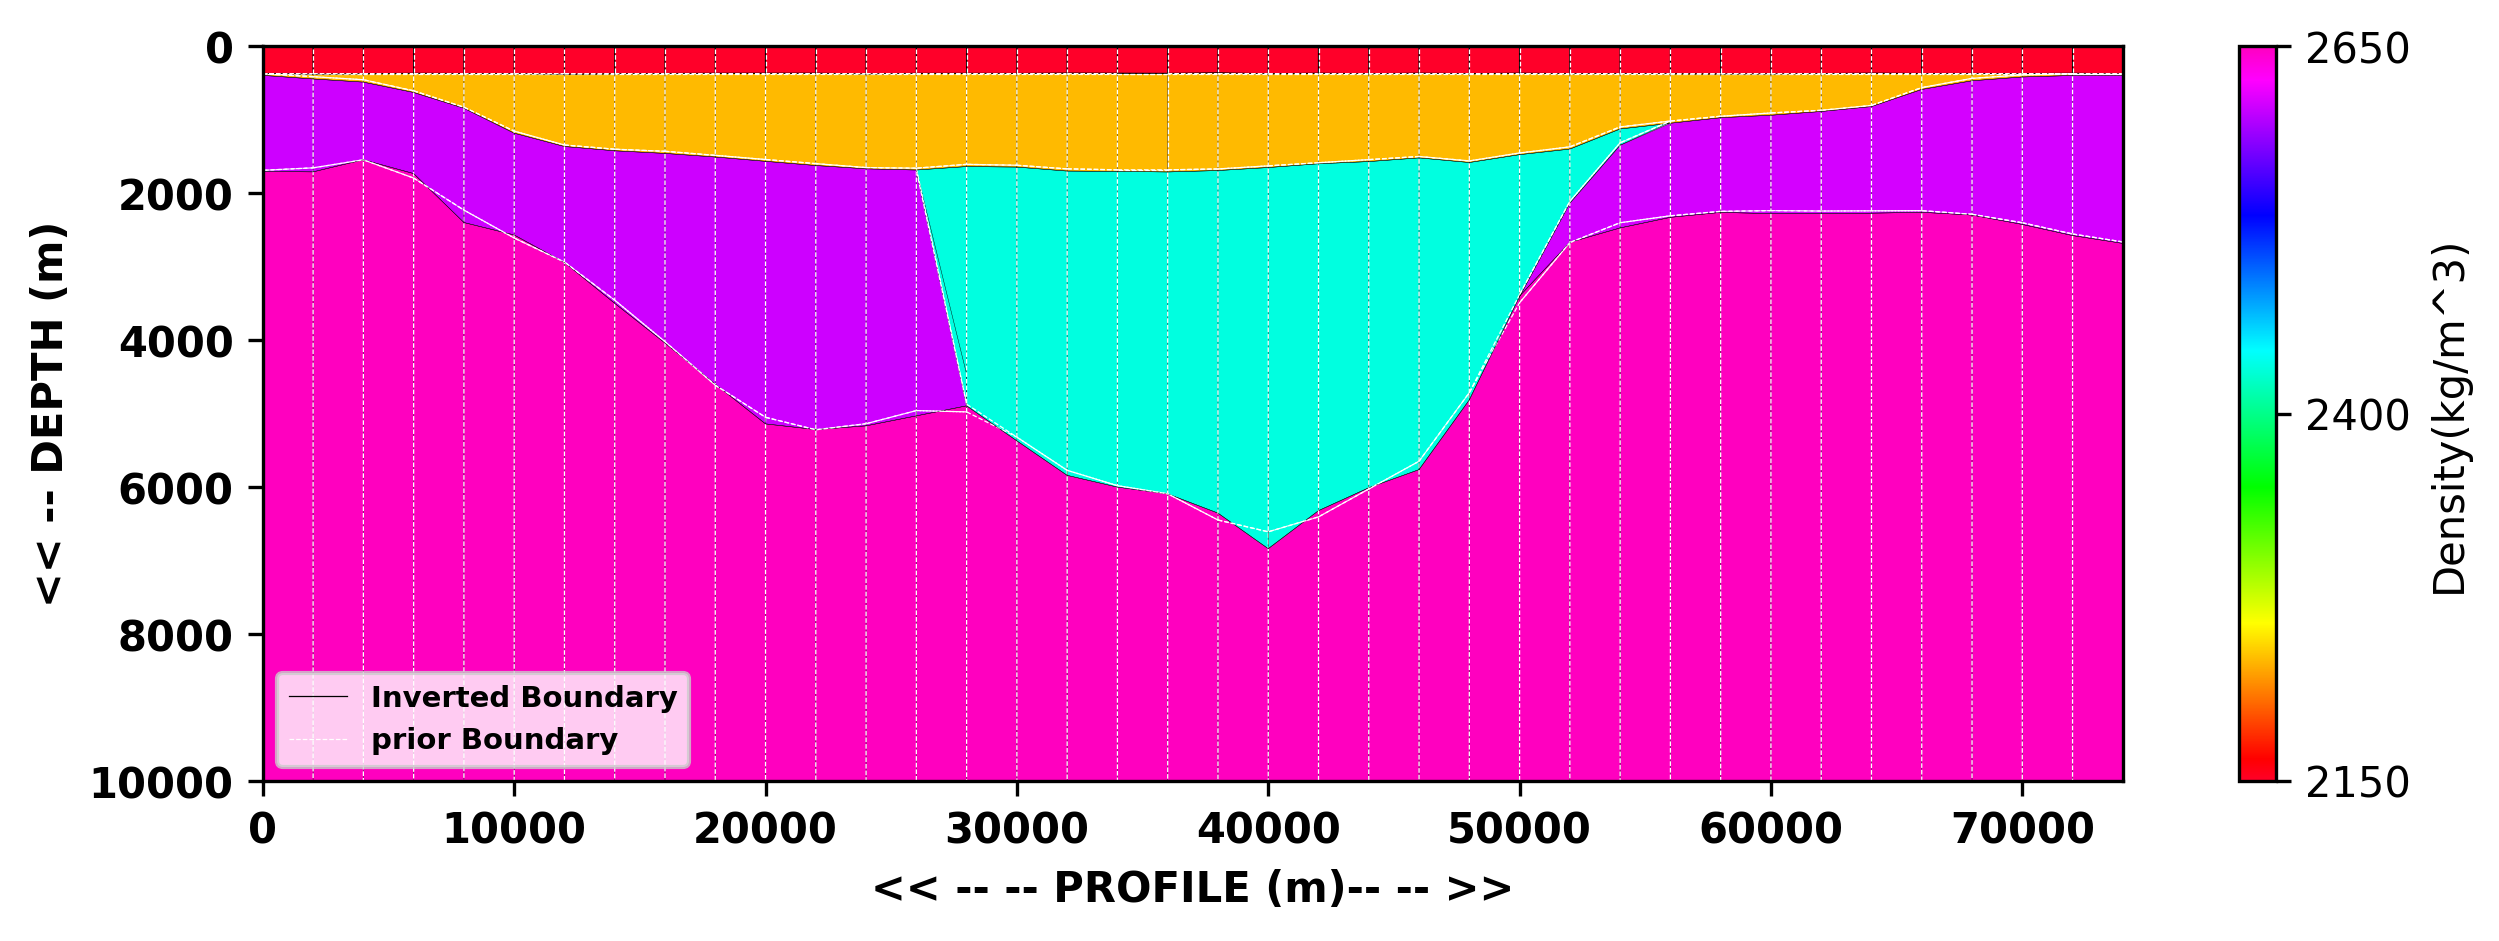

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
# Plot results

seed_points = NUM_INIT_POINTS
plt.figure(figsize=(10, 7),dpi=300)
plt.tight_layout(pad=2)

plt.subplot(211) #PLOTTING ANOMALY

plt.scatter(X[seed_points:], y[seed_points:], c=jnp.arange(1, len(X[seed_points:])+1),
            cmap='viridis', zorder=1)
cbar = plt.colorbar(ticks=np.linspace(1,3,1),label="Exploration step")
plt.plot(X, y, c='green', label='True function', zorder=0) #Observed anomaly
plt.plot(X_test, y_pred, '--', c='red', label='Reconstructed Anomaly', zorder=0) #Reconstructed anomaly using inverted parameters

plt.fill_between(X_test, y_pred - y_sampled.std((0,1)), y_pred + y_sampled.std((0,1)),
                        color='r', alpha=0.2, label="Uncertainty", zorder=0) #Uncertainty of the model


plt.ylabel("Gravity anomaly in mgal",fontsize=10,weight='bold')
plt.legend()
legend_properties = {'weight':'bold','size':'7'}
plt.legend(prop=legend_properties)
plt.yticks(weight='bold')
#plt.yticks(weight='bold',visible=False)
plt.tick_params(labelbottom=False)

cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=2650 #maximum density value in color scale in kg/m^3
minimum_V=2150 #minimum density value in color scale in kg/m^3
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
plt.figure(figsize=(10, 7),dpi=300)
plt.subplot(212)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,3),label='Density(kg/m^3)') #creating colorscale dividng the min to max range in 100 equal values


for i in range(n):
    #choosing the color depending upon the inverted density value of 1st layer
    index_value_V1 = (params1[f'density1'].mean()-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the inverted density value of 6th layer
    index_value_V6 = (params1[f'density6'].mean()-minimum_V)/diff_V
    color_V6 = cmap_V(index_value_V6)
    #choosing the color depending upon the inverted density value of 2nd layer
    index_value_V2 = (params1[f'density2'].mean()-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord1_I = [R00_I[i], R00_I[i+1], R11_I[i+1], R11_I[i]]
    coord2_I = [R22_top_I[i], R22_top_I[i+1], R22_I[i+1], R22_I[i]]
    coord6_I = [R66_top_I[i], R66_top_I[i+1], R66_I[i+1], R66_I[i]]
    xs1_I, ys1_I = zip(*coord1_I) #create lists of x and y values
    xs2_I, ys2_I = zip(*coord2_I) #create lists of x and y values
    xs6_I, ys6_I = zip(*coord6_I) #create lists of x and y values
    #creating a prism using 4 corner co-ordinates using previous results
    coord1_R = [R00[i], R00[i+1], R11[i+1], R11[i]]
    coord2_R = [R22_top[i], R22_top[i+1], R22[i+1], R22[i]]
    coord6_R = [R66_top[i], R66_top[i+1], R66[i+1], R66[i]]
    xs1_R, ys1_R = zip(*coord1_R) #create lists of x and y values
    xs2_R, ys2_R = zip(*coord2_R) #create lists of x and y values
    xs6_R, ys6_R = zip(*coord6_R) #create lists of x and y values

    plt.plot(xs1_I,ys1_I,'k',linewidth=0.3)#plotting each prism of layer 1
    plt.plot(xs1_R,ys1_R,'white',linestyle='dashed',linewidth=0.3)
    plt.fill(xs1_I, ys1_I, facecolor=color_V1)#color filling the prism acc to its inverted density value
    plt.plot(xs2_I,ys2_I,'k',linewidth=0.1)#plotting each prism of layer 2
    plt.fill(xs2_I, ys2_I, facecolor=color_V2)#color filling the prism acc to its inverted density value
    plt.plot(xs6_I,ys6_I,'k',linewidth=0.1)#plotting each prism of layer 6
    plt.fill(xs6_I, ys6_I, facecolor=color_V6)#color filling the prism acc to its inverted density value
    plt.plot(xs2_R,ys2_R,'white',linestyle='dashed',linewidth=0.3)
    plt.plot(xs6_R,ys6_R,'white',linestyle='dashed',linewidth=0.3)

for i in range(len(xss3)-1):
    #choosing the color depending upon the inverted density value of 3rd layer
    index_value_V3 = (params1[f'density3'].mean()-minimum_V)/diff_V
    color_V3 = cmap_V(index_value_V3)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord3_I = [R33_top_I[i], R33_top_I[i+1], R33_I[i+1], R33_I[i]]
    xs3_I, ys3_I = zip(*coord3_I) #create lists of x and y values
    plt.plot(xs3_I,ys3_I,'k',linewidth=0.1)#plotting each prism of layer 3 using inverted result
    plt.fill(xs3_I, ys3_I, facecolor=color_V3)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord3_R = [R33_top[i], R33_top[i+1], R33[i+1], R33[i]]
    xs3_R, ys3_R = zip(*coord3_R) #create lists of x and y values
    plt.plot(xs3_R,ys3_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss4)-1):
    #choosing the color depending upon the inverted density value of 4th layer
    index_value_V4 = (params1[f'density4'].mean()-minimum_V)/diff_V
    color_V4 = cmap_V(index_value_V4)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord4_I = [R44_top_I[i], R44_top_I[i+1], R44_I[i+1], R44_I[i]]
    xs4_I, ys4_I = zip(*coord4_I) #create lists of x and y values
    plt.plot(xs4_I,ys4_I,'k',linewidth=0.1)#plotting each prism of layer 4 using inverted result
    plt.fill(xs4_I, ys4_I, facecolor=color_V4)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord4_R = [R44_top[i], R44_top[i+1], R44[i+1], R44[i]]
    xs4_R, ys4_R = zip(*coord4_R) #create lists of x and y values
    plt.plot(xs4_R,ys4_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss5)-1):
    #choosing the color depending upon the inverted density value of 5th layer
    index_value_V5 = (params1[f'density5'].mean()-minimum_V)/diff_V
    color_V5 = cmap_V(index_value_V5)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord5_I = [R55_top_I[i], R55_top_I[i+1], R55_I[i+1], R55_I[i]]
    xs5_I, ys5_I = zip(*coord5_I) #create lists of x and y values
    plt.plot(xs5_I,ys5_I,'k',linewidth=0.1)#plotting each prism of layer 5 using inverted result
    plt.fill(xs5_I, ys5_I, facecolor=color_V5)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord5_R = [R55_top[i], R55_top[i+1], R55[i+1], R55[i]]
    xs5_R, ys5_R = zip(*coord5_R) #create lists of x and y values
    plt.plot(xs5_R,ys5_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 5 using previous knowledge

    legend_properties = {'weight':'bold','size':'7'}
    plt.legend(['Inverted Boundary','prior Boundary'],prop=legend_properties)
plt.xlim(0,74000)
plt.ylim(10000,0)
plt.xlabel("<< -- -- PROFILE (m)-- -- >>",weight='bold')
plt.ylabel("<< -- DEPTH (m)",weight='bold')
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')


# **BAYESIAN OPTIMIZATION**


Exploration step 1


sample: 100%|██████████| 275/275 [05:33<00:00,  1.21s/it, 15 steps of size 3.73e-01. acc. prob=0.86]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    376.70     48.63    376.79    308.41    451.87     77.57      0.99
  Bottom_depth1_10    377.75     54.24    382.20    287.68    448.24    137.14      0.99
  Bottom_depth1_11    357.11     54.47    352.02    283.51    441.32    113.62      0.99
  Bottom_depth1_12    363.91     54.57    359.84    289.70    450.15    121.83      0.99
  Bottom_depth1_13    391.06     62.22    402.74    282.73    473.57    498.96      0.99
  Bottom_depth1_14    364.57     63.97    357.31    274.30    454.99    100.11      1.01
  Bottom_depth1_15    366.00     54.86    366.42    288.98    453.88    136.99      0.99
  Bottom_depth1_16    388.12     55.43    388.21    305.21    471.87    213.33      0.99
  Bottom_depth1_17    365.60     53.09    353.08    289.05    449.90    204.38      0.99
  Bottom_depth1_18    368.02     55.30    369.78    294.26    461.46    135.22      1.00
  Bottom_depth1_19  

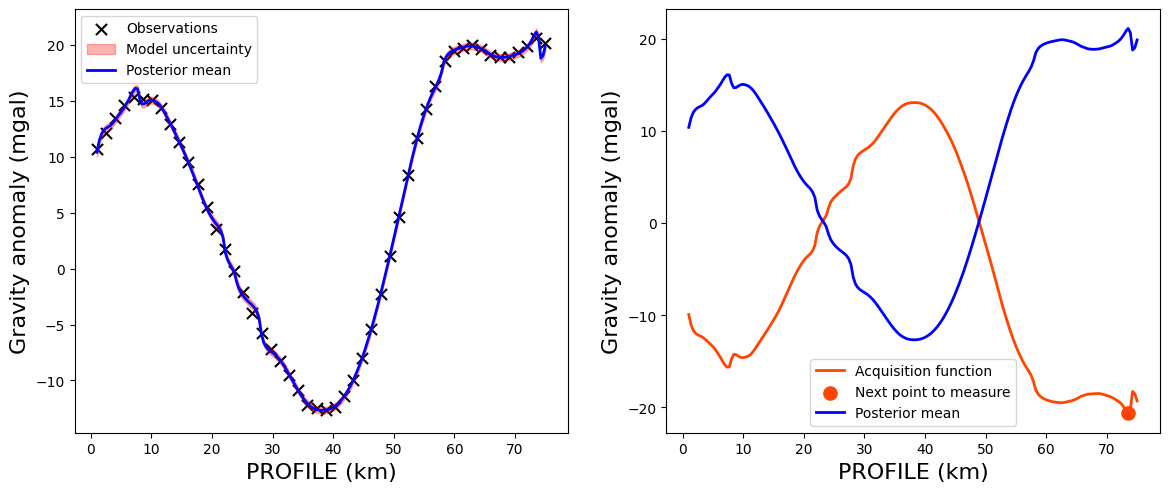


Exploration step 2


sample: 100%|██████████| 275/275 [03:26<00:00,  1.33it/s, 15 steps of size 3.57e-01. acc. prob=0.86]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    378.37     50.34    378.19    313.66    473.71     66.59      1.02
  Bottom_depth1_10    370.11     55.20    369.07    282.64    443.49    139.86      1.00
  Bottom_depth1_11    367.58     48.13    363.60    300.55    445.36    111.97      0.99
  Bottom_depth1_12    368.86     58.20    360.27    284.20    453.17    130.52      0.99
  Bottom_depth1_13    377.50     51.08    384.75    290.66    451.61    110.72      0.99
  Bottom_depth1_14    369.80     60.02    368.55    279.72    453.64    180.64      0.99
  Bottom_depth1_15    378.53     54.51    381.08    309.36    470.97    227.35      0.99
  Bottom_depth1_16    377.78     58.48    374.97    292.46    470.65    189.35      1.01
  Bottom_depth1_17    373.14     55.22    366.05    293.68    454.89    239.37      0.99
  Bottom_depth1_18    369.52     57.66    369.95    283.26    452.27   2603.34      0.99
  Bottom_depth1_19  

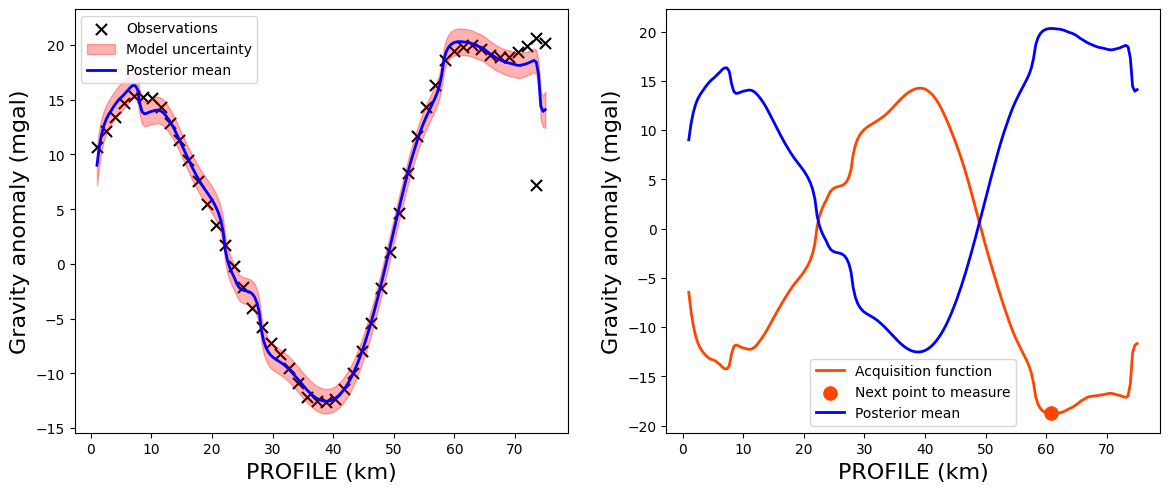

In [ ]:
# Copy the initial observations so that we can re-use them later
Xo, yo = X.copy(), y.copy()
rng_key, rng_key_predict = gpax.utils.get_keys(1)
for i in range(2):
    print("\nExploration step {}".format(i+1))
    # Obtain/update GP posterior
    gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_Inf, mean_fn_prior=Bayes_Inf_prior)
    gp_model.fit(rng_key, Xo, yo, num_warmup = 200, num_samples = 75, num_chains = 1, print_summary=1)
    #Upper confidence bound
    obj = gpax.acquisition.UCB(rng_key_predict, gp_model, X_test, beta= 2, maximize=False, noiseless=True)
    #Expected improvement
    #obj = gpax.acquisition.EI(rng_key_predict, gp_model, X_test, xi=0.01, maximize=False, n=10, noiseless=True) #xi = 0.01
    next_point_idx = obj.argmin()
    #Append the 'suggested' point
    Xo = np.append(Xo, X_test[next_point_idx])
    measured = Bayes_Inf(X_test[next_point_idx], PARAMS) + np.random.normal(0., 0.01)  # we assume that new observations are also noisy
    yo = np.append(yo, measured)
    # Plot observed points, mean prediction, and acqusition function
    y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, noiseless=True, n= 10)
    lower_b = y_pred - y_sampled.std(axis=(0,1))
    upper_b = y_pred + y_sampled.std(axis=(0,1))
    fig, (ax1, ax2) = plt.subplots(1, 2, dpi=100, figsize=(14, 5.5))
    ax1.scatter(Xo[:-1], yo[:-1], marker='x', c='k', label="Observations", s=64)
    ax1.fill_between(X_test, lower_b, upper_b, color='r', alpha=0.3, label="Model uncertainty")
    ax2.plot(X_test, obj, lw=2, c='orangered', label='Acquisition function')
    ax2.scatter(X_test[next_point_idx], obj[next_point_idx], s=90, c='orangered', label='Next point to measure')
    for ax in fig.axes:
        ax.plot(X_test, y_pred, lw=2, c='b', label='Posterior mean')
        ax.set_xlabel("PROFILE (km)", fontsize=16)
        ax.set_ylabel("Gravity anomaly (mgal)", fontsize=16)
        ax.legend(loc='best', fontsize=10)
    plt.show()

In [ ]:
#Making prediction using all the newly discovered points:
rng_key, rng_key_predict = gpax.utils.get_keys(1)
# Update GP posterior
gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=Bayes_Inf, mean_fn_prior=Bayes_Inf_prior)
gp_model.fit(rng_key, Xo, yo, num_warmup = 200, num_samples = 75, num_chains = 1)
# Get GP prediction
y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, n=200)

sample: 100%|██████████| 275/275 [03:21<00:00,  1.37it/s, 15 steps of size 3.25e-01. acc. prob=0.89]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
   Bottom_depth1_1    376.20     50.83    377.65    310.47    473.68     50.64      1.00
  Bottom_depth1_10    364.84     54.29    363.98    274.91    444.06    101.95      0.99
  Bottom_depth1_11    374.32     53.78    375.43    288.68    455.64    315.12      0.99
  Bottom_depth1_12    372.48     58.63    371.03    283.90    449.69    116.63      1.00
  Bottom_depth1_13    374.97     62.31    371.02    274.37    460.49    812.57      0.99
  Bottom_depth1_14    377.54     59.33    379.78    279.77    450.00    191.37      0.99
  Bottom_depth1_15    371.27     56.79    366.88    297.00    461.11    382.24      0.99
  Bottom_depth1_16    383.35     59.30    391.92    290.63    470.03    689.67      1.00
  Bottom_depth1_17    373.18     50.33    376.16    291.73    451.32    209.42      0.99
  Bottom_depth1_18    368.57     56.06    363.32    279.46    441.36    105.96      0.99
  Bottom_depth1_19  

In [ ]:
#Getting inverted parameters
params1 = gp_model.get_samples()
#Defining arrays with inverted results

#bottom depth of layer 1 in meter (sediment layer in the Miocene era)
Bottom_Depth_1st_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_1st_Layer[i]=params1[f'Bottom_depth1_{i+1}'].mean()
#bottom depth of layer 2 in meter (sediment layer in the Paleocene era)
Bottom_Depth_2nd_Layer=np.zeros(n+1)
for i in range(n+1):
    Bottom_Depth_2nd_Layer[i]=params1[f'Bottom_depth2_{i+1}'].mean()
#top depth of layer 6 (basement)
Top_Depth_6th_Layer=np.zeros(n+1)
for i in range(n+1):
    Top_Depth_6th_Layer[i]=params1[f'top_depth6_{i+1}'].mean()
#depth profile between 3rd and 4th layers in meter(western and central sub-basin)
fault1_depth_I=np.zeros(2)
fault1_depth_I[0]=params1[f'fault1_depth_1'].mean()
fault1_depth_I[1]=params1[f'fault1_depth_2'].mean()
#depth profile between 4th and 5th layers in meter(central and eastern sub-basin)
fault2_depth_I=np.zeros(4)
for i in range(4):
    fault2_depth_I[i]=params1[f'fault2_depth_{i+1}'].mean()

In [ ]:
##CREATING POINTS WITH INVERTED RESULTS##

#Creating x co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
xs1=np.zeros(n+1)
xs1[0]=co[0]-(wid[0]*0.5)
for i in range(1,n):
    xs1[i]=co[i-1]+(0.5*wid[i-1])
xs1[n]=xs1[n-1]+wid[n-1]

#Creating z1 (bottom depth) co-ordinate values for 1st layer(sediment layer in the Miocene era) for each prism
zs1=np.zeros(n+1)
for i in range(n+1):
    zs1[i]=Bottom_Depth_1st_Layer[i]

#Creating surface points
zs0=np.zeros(n+1)
R00_I=np.zeros(((n+1),2))
for i in range(n+1):
    R00_I[i]=[xs1[i],zs0[i]]

#Creating points for 1st layer(sediment layer in the Miocene era) bottom
R11_I=np.zeros(((n+1),2))
for i in range(n+1):
    R11_I[i]=[xs1[i],zs1[i]]

#Creating bottom depth co-ordinate values for 6th layer(basement) for each prism
zs6=np.zeros(n+1)
for i in range(n+1):
    zs6[i]=10000
#Creating bottom CO-ordinates for 6th layer(basement) for each prism
R66_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_I[i]=[xs1[i],zs6[i]]
#Creating top depth co-ordinate values for 6th layer(basement) top for each prism
zs6_top=np.zeros(n+1)
for i in range(n+1):
    zs6_top[i]=Top_Depth_6th_Layer[i]
#Creating top points for 6th layer(basement) top for each prism
R66_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R66_top_I[i]=[xs1[i],zs6_top[i]]

#Creating bottom depth co-ordinate values for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
zs2=np.zeros(n+1)
for i in range(n+1):
    zs2[i]=Bottom_Depth_2nd_Layer[i]

#Creating bottom points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_I[i]=[xs1[i],zs2[i]]

#Creating top points for 2nd layer(sediment layer in the Paleocene era) bottom for each prism
R22_top_I=np.zeros(((n+1),2))
for i in range(n+1):
    R22_top_I[i]=[xs1[i],zs1[i]]



In [ ]:
#for 3rd layer(western subbasin)
#x coordinates of 3rd layer
xs3=np.arange(0,29000,2000)
#top depth coordinates of 3rd layer
zs3_top=np.zeros(len(xs3))
for i in range(len(xs3)-1):
    zs3_top[i]=zs2[i]
zs3_top[len(xs3)-1]=fault1_depth_I[1]
#bottom depth coordinates of 3rd layer
zs3=np.zeros(len(xs3))
for i in range(len(xs3)):
    zs3[i]=Top_Depth_6th_Layer[i]
#Creating points for 3rd layer TOP
R33_top_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_top_I[i]=[xs3[i],zs3_top[i]]
#Creating points for 3rd layer bottom
R33_I=np.zeros(((len(xs3)),2))
for i in range(len(xs3)):
    R33_I[i]=[xs3[i],zs3[i]]

#for 4th layer
#x coordinates of 4th layer
xs4=np.arange(26000,57000,2000)
#top depth coordinates of 4th layer
zs4_top=np.zeros(len(xs4))
for i in range(len(xs4)):
    zs4_top[i]=zs2[i+13]
#bottom depth coordinates of 4th layer
zs4=np.zeros(len(xs4))
zs4[0]=fault1_depth_I[0]
#zs4[1]=fault1_depth_I[1]
for i in range(len(xs4)-5):
    zs4[i+2-1]=Top_Depth_6th_Layer[i+15-1]
zs4[len(xs4)-1]=fault2_depth_I[3]
zs4[len(xs4)-2]=fault2_depth_I[2]
zs4[len(xs4)-3]=fault2_depth_I[1]
zs4[len(xs4)-4]=fault2_depth_I[0]
#Creating points for 4th layer TOP depth
R44_top_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_top_I[i]=[xs4[i],zs4_top[i]]
#Creating points for 4th layer bottom depth
R44_I=np.zeros(((len(xs4)),2))
for i in range(len(xs4)):
    R44_I[i]=[xs4[i],zs4[i]]

#for 5th layer
#x coordinates of 4th layer
xs5=np.arange(50000,75000,2000)
#top depth coordinates of 5th layer
zs5_top=np.zeros(len(xs5))
for i in range(len(xs5)-3):
    zs5_top[i+3]=zs2[i+28]
zs5_top[0]=fault2_depth_I[0]
zs5_top[1]=fault2_depth_I[1]
zs5_top[2]=fault2_depth_I[2]
#bottom depth coordinates of 5th layer
zs5=np.zeros(len(xs5))
for i in range(len(xs5)):
    zs5[i]=Top_Depth_6th_Layer[i+25]
#Creating points for 5th layer TOP
R55_top_I=np.zeros(((len(xs5)),2))
for i in range(len(xss5)):
    R55_top_I[i]=[xs5[i],zs5_top[i]]
#Creating points for 5th layer bottom
R55_I=np.zeros(((len(xs5)),2))
for i in range(len(xs5)):
    R55_I[i]=[xs5[i],zs5[i]]

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000')])

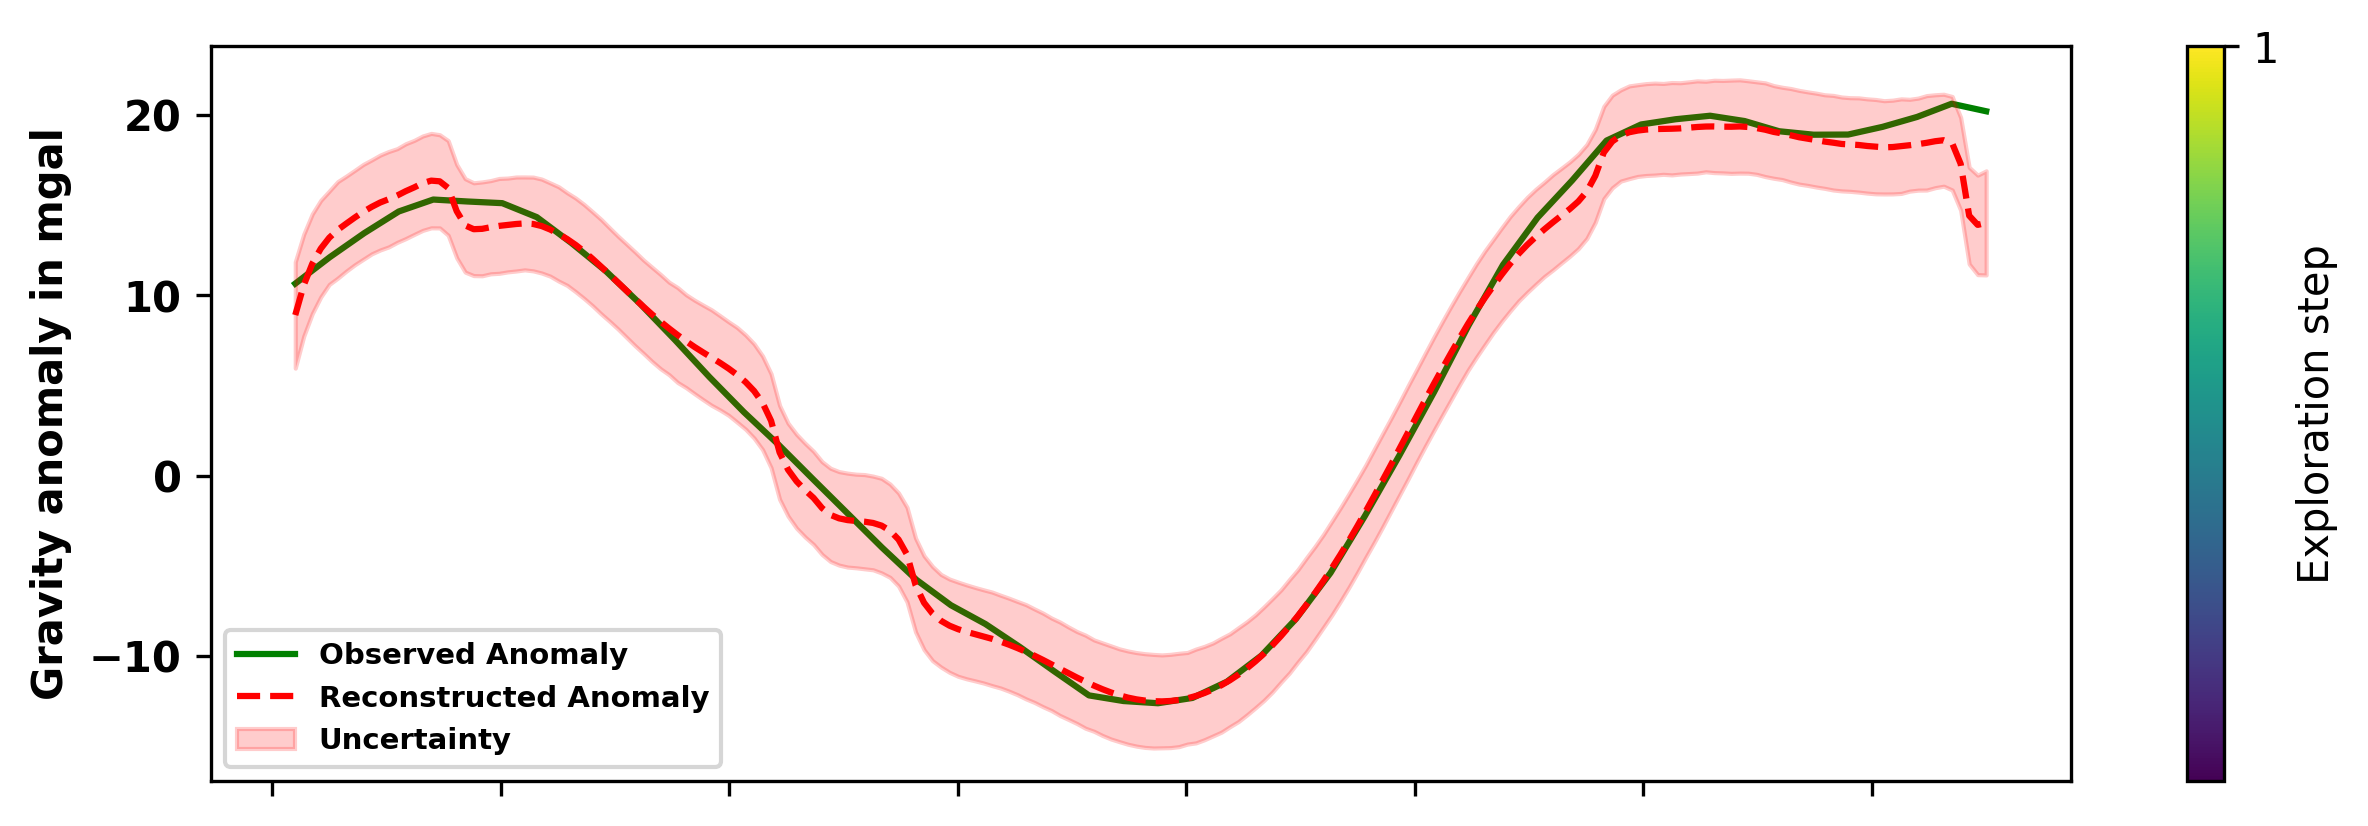

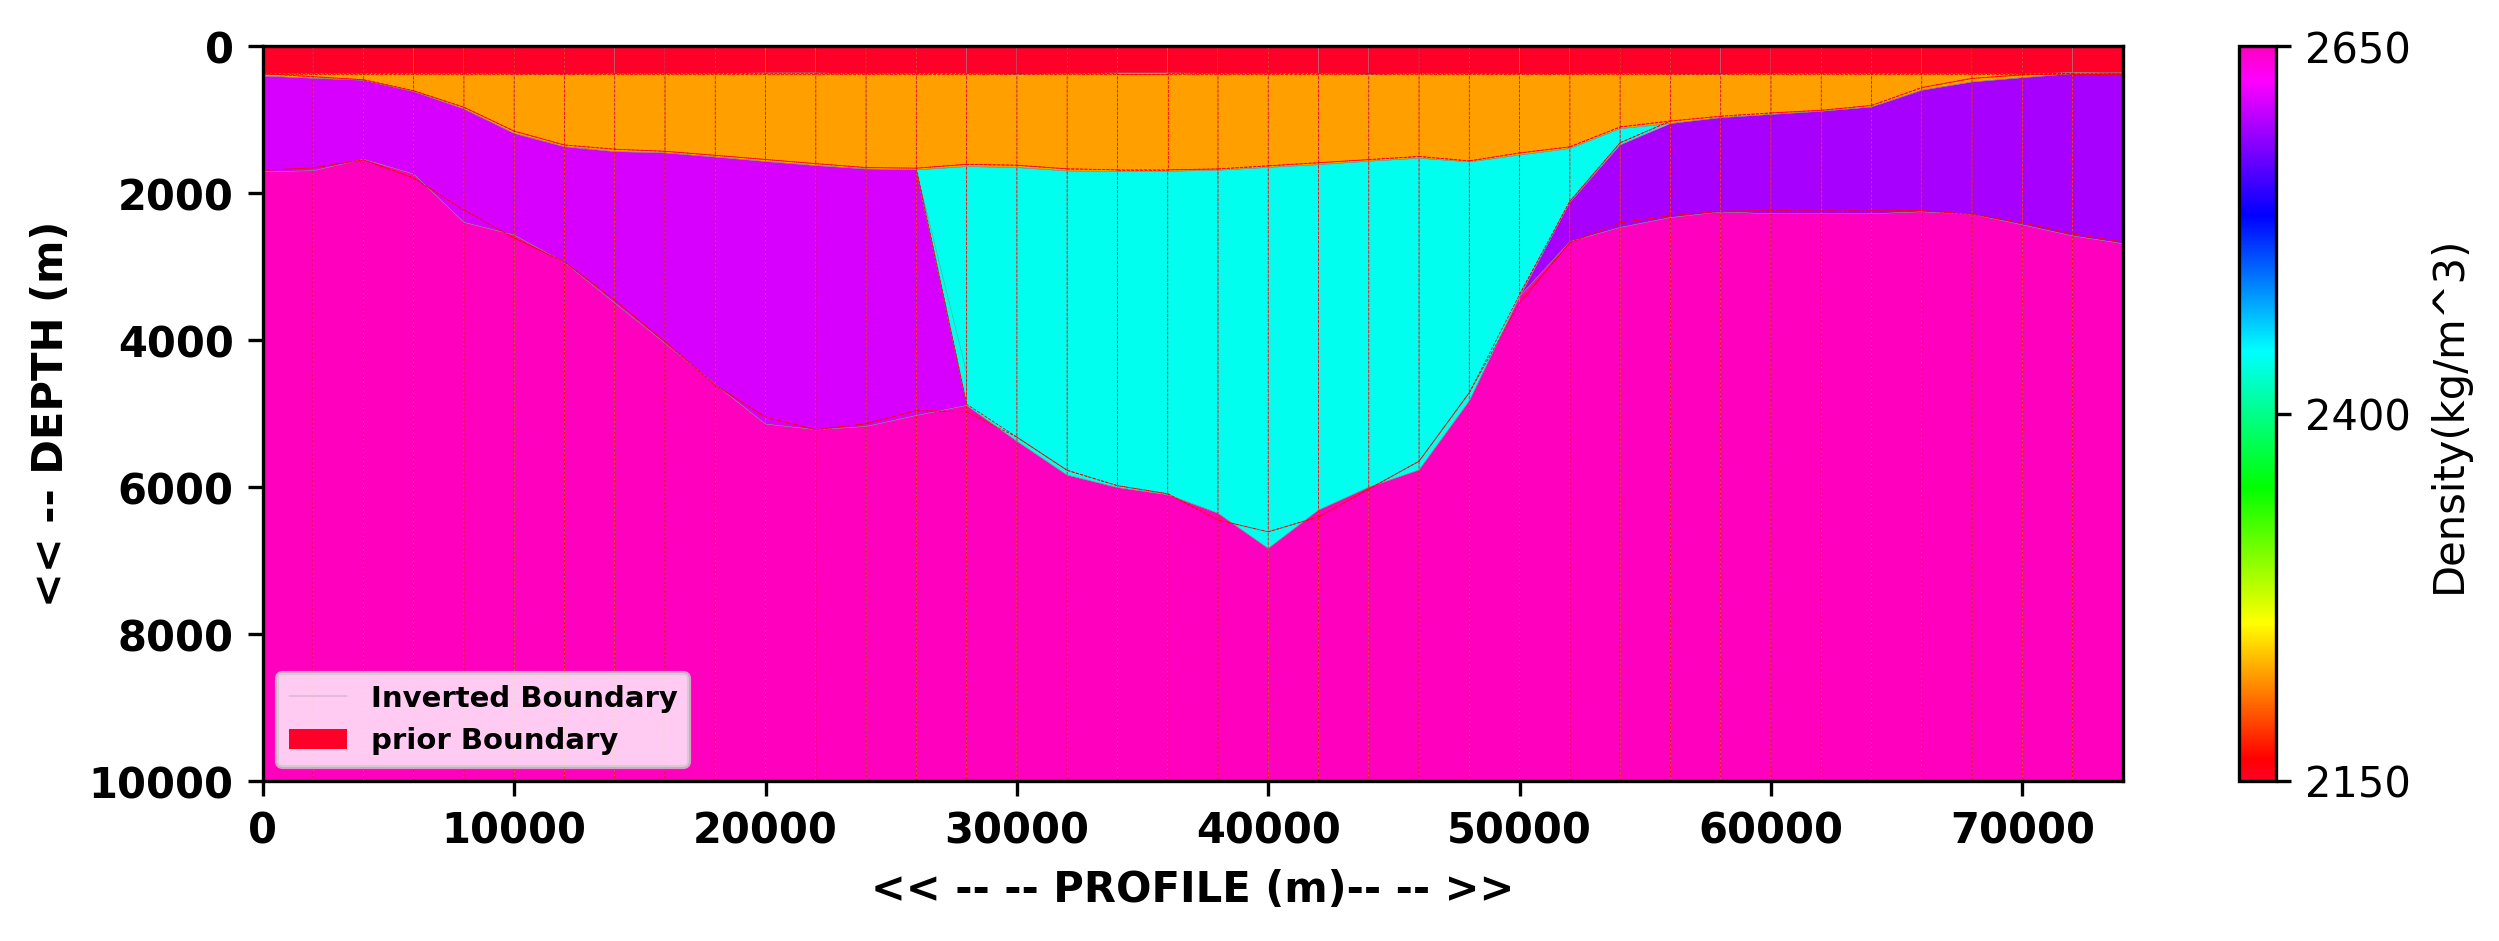

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
# Plot results

seed_points = NUM_INIT_POINTS
plt.figure(figsize=(10, 7),dpi=300)
plt.tight_layout(pad=2)

plt.subplot(211) #PLOTTING ANOMALY

plt.scatter(X[seed_points:], y[seed_points:], c=jnp.arange(1, len(X[seed_points:])+1),
            cmap='viridis', zorder=1)
cbar = plt.colorbar(ticks=np.linspace(1,3,1),label="Exploration step")
plt.plot(X, y, c='green', label='Observed Anomaly', zorder=0) #Observed anomaly
plt.plot(X_test, y_pred, '--', c='red', label='Reconstructed Anomaly', zorder=0) #Reconstructed anomaly using inverted parameters

plt.fill_between(X_test, y_pred - y_sampled.std((0,1)), y_pred + y_sampled.std((0,1)),
                        color='r', alpha=0.2, label="Uncertainty", zorder=0) #Uncertainty of the model


plt.ylabel("Gravity anomaly in mgal",fontsize=10,weight='bold')
plt.legend()
legend_properties = {'weight':'bold','size':'7'}
plt.legend(prop=legend_properties)
plt.yticks(weight='bold')
#plt.yticks(weight='bold',visible=False)
plt.tick_params(labelbottom=False)

cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=2650 #maximum density value in color scale in kg/m^3
minimum_V=2150 #minimum density value in color scale in kg/m^3
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
plt.figure(figsize=(10, 7),dpi=300)
plt.subplot(212)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,3),label='Density(kg/m^3)') #creating colorscale dividng the min to max range in 100 equal values


for i in range(n):
    #choosing the color depending upon the inverted density value of 1st layer
    index_value_V1 = (params1[f'density1'].mean()-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the inverted density value of 6th layer
    index_value_V6 = (params1[f'density6'].mean()-minimum_V)/diff_V
    color_V6 = cmap_V(index_value_V6)
    #choosing the color depending upon the inverted density value of 2nd layer
    index_value_V2 = (params1[f'density2'].mean()-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord1_I = [R00_I[i], R00_I[i+1], R11_I[i+1], R11_I[i]]
    coord2_I = [R22_top_I[i], R22_top_I[i+1], R22_I[i+1], R22_I[i]]
    coord6_I = [R66_top_I[i], R66_top_I[i+1], R66_I[i+1], R66_I[i]]
    xs1_I, ys1_I = zip(*coord1_I) #create lists of x and y values
    xs2_I, ys2_I = zip(*coord2_I) #create lists of x and y values
    xs6_I, ys6_I = zip(*coord6_I) #create lists of x and y values
    #creating a prism using 4 corner co-ordinates using previous results
    coord1_R = [R00[i], R00[i+1], R11[i+1], R11[i]]
    coord2_R = [R22_top[i], R22_top[i+1], R22[i+1], R22[i]]
    coord6_R = [R66_top[i], R66_top[i+1], R66[i+1], R66[i]]
    xs1_R, ys1_R = zip(*coord1_R) #create lists of x and y values
    xs2_R, ys2_R = zip(*coord2_R) #create lists of x and y values
    xs6_R, ys6_R = zip(*coord6_R) #create lists of x and y values

    plt.plot(xs1_I,ys1_I,'k',linewidth=0.3)#plotting each prism of layer 1
    plt.plot(xs1_R,ys1_R,'white',linestyle='dashed',linewidth=0.5)
    plt.fill(xs1_I, ys1_I, facecolor=color_V1)#color filling the prism acc to its inverted density value
    plt.plot(xs2_I,ys2_I,'k',linewidth=0.1)#plotting each prism of layer 2
    plt.fill(xs2_I, ys2_I, facecolor=color_V2)#color filling the prism acc to its inverted density value
    plt.plot(xs6_I,ys6_I,'k',linewidth=0.1)#plotting each prism of layer 6
    plt.fill(xs6_I, ys6_I, facecolor=color_V6)#color filling the prism acc to its inverted density value
    plt.plot(xs2_R,ys2_R,'white',linestyle='dashed',linewidth=0.3)
    plt.plot(xs6_R,ys6_R,'white',linestyle='dashed',linewidth=0.3)

for i in range(len(xss3)-1):
    #choosing the color depending upon the inverted density value of 3rd layer
    index_value_V3 = (params1[f'density3'].mean()-minimum_V)/diff_V
    color_V3 = cmap_V(index_value_V3)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord3_I = [R33_top_I[i], R33_top_I[i+1], R33_I[i+1], R33_I[i]]
    xs3_I, ys3_I = zip(*coord3_I) #create lists of x and y values
    plt.plot(xs3_I,ys3_I,'k',linewidth=0.1)#plotting each prism of layer 3 using inverted result
    plt.fill(xs3_I, ys3_I, facecolor=color_V3)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord3_R = [R33_top[i], R33_top[i+1], R33[i+1], R33[i]]
    xs3_R, ys3_R = zip(*coord3_R) #create lists of x and y values
    plt.plot(xs3_R,ys3_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss4)-1):
    #choosing the color depending upon the inverted density value of 4th layer
    index_value_V4 = (params1[f'density4'].mean()-minimum_V)/diff_V
    color_V4 = cmap_V(index_value_V4)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord4_I = [R44_top_I[i], R44_top_I[i+1], R44_I[i+1], R44_I[i]]
    xs4_I, ys4_I = zip(*coord4_I) #create lists of x and y values
    plt.plot(xs4_I,ys4_I,'k',linewidth=0.1)#plotting each prism of layer 4 using inverted result
    plt.fill(xs4_I, ys4_I, facecolor=color_V4)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord4_R = [R44_top[i], R44_top[i+1], R44[i+1], R44[i]]
    xs4_R, ys4_R = zip(*coord4_R) #create lists of x and y values
    plt.plot(xs4_R,ys4_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 4 using previous knowledge

for i in range(len(xss5)-1):
    #choosing the color depending upon the inverted density value of 5th layer
    index_value_V5 = (params1[f'density5'].mean()-minimum_V)/diff_V
    color_V5 = cmap_V(index_value_V5)
    #creating a prism using 4 corner co-ordinates using inverted results
    coord5_I = [R55_top_I[i], R55_top_I[i+1], R55_I[i+1], R55_I[i]]
    xs5_I, ys5_I = zip(*coord5_I) #create lists of x and y values
    plt.plot(xs5_I,ys5_I,'k',linewidth=0.1)#plotting each prism of layer 5 using inverted result
    plt.fill(xs5_I, ys5_I, facecolor=color_V5)#color filling the prism acc to its inverted density value
    #creating a prism using 4 corner co-ordinates using previous results
    coord5_R = [R55_top[i], R55_top[i+1], R55[i+1], R55[i]]
    xs5_R, ys5_R = zip(*coord5_R) #create lists of x and y values
    plt.plot(xs5_R,ys5_R,'white',linestyle='dashed',linewidth=0.3)#plotting each prism of layer 5 using previous knowledge

    legend_properties = {'weight':'bold','size':'7'}
    plt.legend(['Inverted Boundary','prior Boundary'],prop=legend_properties)
plt.xlim(0,74000)
plt.ylim(10000,0)
plt.xlabel("<< -- -- PROFILE (m)-- -- >>",weight='bold')
plt.ylabel("<< -- DEPTH (m)",weight='bold')
plt.xticks(weight= 'bold')
plt.yticks(weight= 'bold')
